<a href="https://colab.research.google.com/github/barnaor97/reaserch/blob/main/%D7%AA%D7%96%D7%94_%D7%A1%D7%99%D7%93%D7%95%D7%A8_input.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CLOUD SCORE PLUS ENGINE - READ IF IT CAN HELP, MAYBE BETTER PERFORMANCE ALSO, INSTEAD OF THE CLOUD CLEANING. so to download them instead of the Sentinel 2.

INSTEAD OF PATCH, TAKE PIXELS MAYBE. NEED TO CHECK THIS.

GETPIXELS & COMPUTE PIXLES INSTEAD OF EXPORT.

THE LABEL IS AS MASK. EACH MASK MAY HAVE BOTH FIRE AND NOT FIRE.

EEE- קלסיפיקציה של פוליגונים, tiles-לעבוד עם כל tile בנפרד, download in the correct scale.

Foundations models- traind models- a fast way to observe the accuracy and etc i can reach to. Check Prithvi as a foundation model. also- check other data sets to see if to take pixel or patch. -categories (severity level?), resolution

add specific bands: swir, nir

In [ ]:
# ----------------------------------------
# Best-practice tabular dataset for fire detection and severity proxy
# Sentinel-2 SR + Cloud Score+ + NDVI/NBR + dNBR + RBR
# Includes neighborhood mean and std (default 3x3)
# Balanced burned vs background, matched by date and local area
# ----------------------------------------

!pip install -U geemap
import ee, geemap

ee.Authenticate()
ee.Initialize(project='bar-project-457815')

ASSET_COLLECTION = "projects/bar-project-457815/assets/s2_monthly_image_collection"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 479.3/479.3 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.9 MB/s eta 0:00:00
  Attempting uninstall: earthengine-api
    Found existing installation: earthengine-api 1.5.24
    Uninstalling earthengine-api-1.5.24:
      Successfully uninstalled earthengine-api-1.5.24
  Attempting uninstall: geemap
    Found existing installation: geemap 0.35.3
    Uninstalling geemap-0.35.3:
      Successfully uninstalled geemap-0.35.3


In [ ]:
# -------------------------------------------------------
# 1) Load ROI, masks, and fire ground truth
# -------------------------------------------------------
working_area = ee.FeatureCollection("projects/bar-project-457815/assets/gaza_envelope_for_decell_Dissolve")
region = working_area.geometry()

landuse = ee.FeatureCollection("projects/bar-project-457815/assets/otef_landuse")
human_infra_fc = ee.FeatureCollection("projects/bar-project-457815/assets/human_infrastructure_mask_utm36n")

landuse_mask = (landuse
                .filter(ee.Filter.neq("FCODE", 501))
                .reduceToImage(["FCODE"], ee.Reducer.first())
                .gt(0))

human_infra_mask = (human_infra_fc
                    .reduceToImage(["Shape_Area"], ee.Reducer.count())
                    .gt(0))

final_mask = landuse_mask.And(human_infra_mask.Not())
fires_truth = (ee.FeatureCollection("projects/bar-project-457815/assets/fires_scars_otef_6991")
               .filterBounds(region)
               .map(lambda f: f.set("geom_type", f.geometry().type()))
               .filter(ee.Filter.inList("geom_type", ["Polygon", "MultiPolygon"]))
               .map(lambda f: f.set({
                    "fire_date": ee.Date(ee.Number(f.get("FireDate"))),
                    "fire_year": ee.Date(ee.Number(f.get("FireDate"))).get("year"),
                    "system:time_start": ee.Number(f.get("FireDate"))
                })))


START = ee.Date("2017-01-01").millis()
END   = ee.Date("2025-12-31").millis()
fires_clean = fires_truth.filter(ee.Filter.rangeContains("FireDate", START, END))

print("Fire polygons (clean):", fires_clean.size().getInfo())

# A single raster to test "is this pixel inside ANY fire polygon? (from all over the years)"
burned_any = ee.Image(0).toByte().paint(fires_clean, 1).rename("burned_any")

# -------------------------------------------------------
# 2) Load Sentinel-2 SR + Cloud Score+ and build clean collection
# Use 20m scale because SWIR/red-edge are 20m (good practice for NBR & red-edge indices)
# -------------------------------------------------------
DATE_START = "2017-01-01"
DATE_END   = "2025-12-31"

SCALE = 20
CLEAR_THRESH = 0.60

# Core + red-edge + SWIR
BANDS = ["B2","B3","B4","B5","B6","B7","B8","B8A","B11","B12"]

s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
      .filterBounds(region)
      .filterDate(DATE_START, DATE_END)
      .select(BANDS))

csplus = (ee.ImageCollection("GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED")
          .filterBounds(region)
          .filterDate(DATE_START, DATE_END))

# Attach cs_cdf to S2 images
s2_with_cs = s2.linkCollection(csplus, ["cs_cdf"])

def mask_with_cs(img):
    return (img
            .updateMask(img.select("cs_cdf").gte(CLEAR_THRESH))
            .select(BANDS)
            .updateMask(final_mask)
            .toFloat())

s2_clean = ee.ImageCollection(s2_with_cs.map(mask_with_cs))
print("Clean Sentinel-2 images over ROI:", s2_clean.size().getInfo())


#todo- save as assets to my project- for each month for all the reaerch area, with the indexes and the wave length i need. (montlhy image collection as asset)
# לטעון את הצורות על הראסטרים האלו ולהגיד לפיקסל שיקבל עוד טבלה אחת שהיא עושה תוית של נשרף או לא נשרף (אחד או 0) האם השריפה קרתה בפיקסל המסוים בחודש המסוים בשנה המסוימת
# ואז אפשר לשאול שאלות למשל מה הפיקסל שנשרף הכי הרבה פעמים וכו. יש לי פה סטים של תמונות לאורך זמן ועליהן אוכל לתשאל

Fire polygons (clean): 2439
Clean Sentinel-2 images over ROI: 1295


In [ ]:
img = s2_clean.first()
proj = img.select("B11").projection()
print("Projection:", proj.getInfo())
print("CRS:", proj.crs().getInfo())
print("Transform:", proj.transform().getInfo())

Projection: {'type': 'Projection', 'crs': 'EPSG:32636', 'transform': [20, 0, 600000, 0, -20, 3500040]}
CRS: EPSG:32636
Transform: PARAM_MT["Affine", 
  PARAMETER["num_row", 3], 
  PARAMETER["num_col", 3], 
  PARAMETER["elt_0_0", 20.0], 
  PARAMETER["elt_0_2", 600000.0], 
  PARAMETER["elt_1_1", -20.0], 
  PARAMETER["elt_1_2", 3500040.0]]


In [ ]:
# -------------------------------------------------------
# 3) Build MONTHLY MEAN composites (clean S2) + more indices + quality
#    and export EACH MONTH as an Image Asset to your folder
# -------------------------------------------------------

ASSET_FOLDER = "projects/bar-project-457815/assets/s2_monthly_image_collection"
CRS = "EPSG:32636"
SCALE = 20
MAX_PIXELS = 1e13

# Keep your current bands (10m + 20m); exported at 20m -> 10m bands will be resampled
BANDS = ["B2","B3","B4","B5","B6","B7","B8","B8A","B11","B12"]

# Indices to include in the monthly asset
INDICES = [
    "NDVI","EVI","SAVI","NDRE",
    "NDMI","MSI","NDWI","MNDWI",
    "NBR","NBR2","MIRBI","BSI",
    "BAIS2"
]

def add_indices(img_ref):
    eps = ee.Image.constant(1e-6)

    b2  = img_ref.select("B2")   # Blue
    b3  = img_ref.select("B3")   # Green
    b4  = img_ref.select("B4")   # Red
    b5  = img_ref.select("B5")   # Red-edge 1
    b8  = img_ref.select("B8")   # NIR
    b8a = img_ref.select("B8A")  # NIR narrow
    b11 = img_ref.select("B11")  # SWIR1
    b12 = img_ref.select("B12")  # SWIR2

    # Core
    ndvi = img_ref.normalizedDifference(["B8", "B4"]).rename("NDVI")
    ndmi = img_ref.normalizedDifference(["B8", "B11"]).rename("NDMI")
    nbr  = img_ref.normalizedDifference(["B8", "B12"]).rename("NBR")

    # Vegetation robust
    evi = (b8.subtract(b4)
           .multiply(2.5)
           .divide(b8.add(b4.multiply(6)).subtract(b2.multiply(7.5)).add(1).add(eps))
           .rename("EVI"))

    L = ee.Image.constant(0.5)
    savi = (b8.subtract(b4)
            .multiply(L.add(1))
            .divide(b8.add(b4).add(L).add(eps))
            .rename("SAVI"))

    ndre = (b8a.subtract(b5)
            .divide(b8a.add(b5).add(eps))
            .rename("NDRE"))

    # Burn / SWIR focused
    nbr2 = (b11.subtract(b12)
            .divide(b11.add(b12).add(eps))
            .rename("NBR2"))

    msi = (b11.divide(b8.add(eps))).rename("MSI")  # SWIR1 / NIR

    mirbi = (b12.multiply(10).subtract(b11.multiply(9.8)).add(2)).rename("MIRBI")

    bsi = ((b11.add(b4).subtract(b8.add(b2)))
           .divide(b11.add(b4).add(b8).add(b2).add(eps))
           .rename("BSI"))

    # Water-related (helps avoid confusion with wet soil/irrigation)
    ndwi  = (b3.subtract(b8)).divide(b3.add(b8).add(eps)).rename("NDWI")      # McFeeters
    mndwi = (b3.subtract(b11)).divide(b3.add(b11).add(eps)).rename("MNDWI")   # Xu

    # BAIS2 (your original idea)
    term1 = ee.Image(1).subtract(b11.multiply(b12).multiply(b8a).divide(b4.add(eps)).sqrt())
    term2 = b12.subtract(b8a).divide(b12.add(b8a).add(eps).sqrt()).add(1)
    bais2 = term1.multiply(term2).rename("BAIS2")

    return img_ref.addBands([
        ndvi, evi, savi, ndre,
        ndmi, msi, ndwi, mndwi,
        nbr, nbr2, mirbi, bsi,
        bais2
    ])

def monthly_mean_image(year, month):
    start = ee.Date.fromYMD(year, month, 1)
    end   = start.advance(1, "month")

    ic = s2_clean.filterDate(start, end)

    # Convert S2_SR to reflectance [0..1] for stable index math
    ic_ref = ic.map(lambda img: img.select(BANDS).multiply(0.0001).copyProperties(img, img.propertyNames()))
    ic_ref = ic_ref.map(add_indices)

    # Monthly mean composite (per pixel)
    comp = ic_ref.select(BANDS + INDICES).mean()

    # Quality bands
    n_obs_valid = ic_ref.select("B4").count().rename("n_obs_valid")  # per-pixel valid obs count
    n_images_in_month = ee.Number(ic_ref.size())                     # scalar
    pct_valid = n_obs_valid.divide(n_images_in_month).rename("pct_valid")

    out = (comp
           .addBands([n_obs_valid, pct_valid])
           .set({
               "year": year,
               "month": month,
               "month_start": start.format("YYYY-MM-dd"),
               "n_images_in_month": n_images_in_month,
               "system:time_start": start.millis()
           })
           .clip(region))

    return out

def export_month_to_asset(year, month):
    img = monthly_mean_image(year, month)
    ym = f"{int(year)}_{int(month):02d}"
    desc = f"s2_monthly_mean_{ym}"
    asset_id = f"{ASSET_COLLECTION}/{desc}"

    task = ee.batch.Export.image.toAsset(
        image=img,
        description=desc,
        assetId=asset_id,
        region=region,
        scale=SCALE,
        crs=CRS,
        maxPixels=MAX_PIXELS,
        pyramidingPolicy={'default': 'mean'}
    )
    task.start()
    return task

# -------------------------------------------------------
# Run exports (start small, then scale up)
# -------------------------------------------------------

# Recommended test: one year run: 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025
tasks = []
for y in [2025]:
    for m in range(1, 13):
        tasks.append(export_month_to_asset(y, m))

print(f"{len(tasks)} exported tasks for year 2017,2018,2019,2020,2021,2022,2023,2024,2025")

# When you're happy, export all years:
# tasks = []
# for y in range(2017, 2026):
#     for m in range(1, 13):
#         tasks.append(export_month_to_asset(y, m))
# print(f"Started {len(tasks)} export tasks (2017-2025).")

12 exported tasks for year 2017,2018,2019,2020,2021,2022,2023,2024,2025


build a monthly label ImageCollection that is perfectly aligned (same CRS/scale/grid) with your monthly Sentinel-2 composites.

You already have:
	•	monthly composites (bands + indices + quality) saved per month
	•	fires_clean polygons with an exact FireDate (millis)

Now you want GT: for each month, a raster band burned_this_month (0/1) where each pixel = 1 if it falls inside a fire polygon whose FireDate is inside that month.

Recommended workflow (clean + scalable)

Step 3A — Create a separate asset collection for labels

Create a new ImageCollection asset in the UI, e.g.:
projects/bar-project-457815/assets/fire_monthly_labels

(Keeping labels separate is cleaner than mixing them into the spectral assets; later you can join them by system:time_start.)

Step 3B — For each (year, month): rasterize polygons that happened in that month

Core idea:
	1.	fires_m = fires_clean filtered by FireDate ∈ [month_start, month_end)
	2.	label = ee.Image(0).paint(fires_m, 1) → 1 inside polygons, 0 elsewhere
	3.	set system:time_start = month_start.millis()
	4.	export as asset fire_label_YYYY_MM to the label collection

Step 3C — Later: join labels + features

Once you have both collections saved with system:time_start, you can:
	•	sample pixels for training from both in sync (same month)
	•	or compute derived GT maps like:
	•	fire_count per pixel = sum over months
	•	last_fire_date per pixel = last month where label==1
	•	“recovery” features after last fire, etc.

In [ ]:
# -------------------------------------------------------
# 4) Build MONTHLY FIRE LABELS (0/1) from FireDate polygons
#    and export EACH MONTH as an Image Asset
# -------------------------------------------------------

LABEL_COLLECTION = "projects/bar-project-457815/assets/fire_monthly_labels"

CRS = "EPSG:32636"
SCALE = 20
MAX_PIXELS = 1e13

def monthly_fire_label_image(year, month):
    start = ee.Date.fromYMD(year, month, 1)
    end   = start.advance(1, "month")

    # Now that your features have system:time_start, this is the best way:
    fires_m = fires_clean.filterDate(start, end)

    label = (ee.Image(0).toByte()
             .paint(fires_m, 1)
             .rename("burned_this_month")
             .clip(region)
             .unmask(0)
             .set({
                 "year": year,
                 "month": month,
                 "month_start": start.format("YYYY-MM-dd"),
                 "n_fire_polygons": fires_m.size(),
                 "system:time_start": start.millis()
             }))
    return label

def export_monthly_fire_label_to_asset(year, month):
    img = monthly_fire_label_image(year, month)

    ym = f"{int(year)}_{int(month):02d}"
    desc = f"fire_label_{ym}"
    asset_id = f"{LABEL_COLLECTION}/{desc}"

    task = ee.batch.Export.image.toAsset(
        image=img,
        description=desc,
        assetId=asset_id,
        region=region,
        scale=SCALE,
        crs=CRS,
        maxPixels=MAX_PIXELS
    )
    task.start()
    return task

# ---- Run a small test first ----
tasks = []
for y in [2025]:
    for m in range(1, 13):
        tasks.append(export_monthly_fire_label_to_asset(y, m))

print(f"Started {len(tasks)} fire-label export tasks for year 2017, 2018,2019, 2020, 2021, 2022, 2023,2024,2025.")

Started 12 fire-label export tasks for year 2017, 2018,2019, 2020, 2021, 2022, 2023,2024,2025.


for the harmonic model:



In [ ]:
# ============================================================
# STEP: Compute seasonal baseline (mean, median, std)
#       from 2017-2019 reference period
#       and export monthly anomaly collection
# ============================================================

# ---- Asset paths ----
ASSET_COLLECTION      = "projects/bar-project-457815/assets/s2_monthly_image_collection"
BASELINE_MEAN_FOLDER  = "projects/bar-project-457815/assets/seasonal_baseline_mean"
BASELINE_MEDIAN_FOLDER= "projects/bar-project-457815/assets/seasonal_baseline_median"
BASELINE_STD_FOLDER   = "projects/bar-project-457815/assets/seasonal_baseline_std"
ANOMALY_FOLDER        = "projects/bar-project-457815/assets/monthly_anomaly"

CRS        = "EPSG:32636"
SCALE      = 20
MAX_PIXELS = 1e13

# Bands to include — same 25 as your composites
# (reflectance bands + indices + quality)
ALL_BANDS = [
    "B2","B3","B4","B5","B6","B7","B8","B8A","B11","B12",
    "NDVI","EVI","SAVI","NDRE","NDMI","MSI",
    "NDWI","MNDWI","NBR","NBR2","MIRBI","BSI","BAIS2",
    "n_obs_valid","pct_valid"
]

# Load your full monthly composite collection
ic_full = ee.ImageCollection(ASSET_COLLECTION)

# ============================================================
# PART 1 — Compute baseline per calendar month (2017–2019)
# ============================================================
# Note: using 2017–2019 as reference period (least disturbed).
# median is preferred over mean — robust to the small fires
# that did occur in those years.
# We save mean, median, AND std so we can compute Z-score anomalies.

# Filter to reference period only
ic_ref = ic_full.filter(
    ee.Filter.And(
        ee.Filter.gte("year", 2017),
        ee.Filter.lte("year", 2019)
    )
)

print("Images in reference period (2017–2019):", ic_ref.size().getInfo())

baseline_tasks = []

for month in range(1, 13):

    # All images from this calendar month across 2017–2019
    ic_month = ic_ref.filter(ee.Filter.eq("month", month))

    n = ic_month.size().getInfo()
    print(f"  Month {month:02d}: {n} images in reference period")

    # --- Mean ---
    baseline_mean = (ic_month
                     .select(ALL_BANDS)
                     .mean()
                     .rename(ALL_BANDS)
                     .set({
                         "month": month,
                         "baseline_type": "mean",
                         "reference_years": "2017-2019",
                         "system:time_start": ee.Date.fromYMD(2018, month, 1).millis()
                     })
                     .clip(region))

    # --- Median ---
    baseline_median = (ic_month
                       .select(ALL_BANDS)
                       .median()
                       .rename(ALL_BANDS)
                       .set({
                           "month": month,
                           "baseline_type": "median",
                           "reference_years": "2017-2019",
                           "system:time_start": ee.Date.fromYMD(2018, month, 1).millis()
                       })
                       .clip(region))

    # --- Std dev ---
    # GEE reducer: stdDev across the collection
    baseline_std = (ic_month
                    .select(ALL_BANDS)
                    .reduce(ee.Reducer.stdDev())
                    # reduce() appends "_stdDev" to band names — rename back
                    .rename([b + "_stdDev" for b in ALL_BANDS])
                    .rename(ALL_BANDS)
                    .set({
                        "month": month,
                        "baseline_type": "std",
                        "reference_years": "2017-2019",
                        "system:time_start": ee.Date.fromYMD(2018, month, 1).millis()
                    })
                    .clip(region))

    mm = f"{month:02d}"

    # Export mean
    t1 = ee.batch.Export.image.toAsset(
        image=baseline_mean,
        description=f"baseline_mean_{mm}",
        assetId=f"{BASELINE_MEAN_FOLDER}/baseline_mean_{mm}",
        region=region, scale=SCALE, crs=CRS, maxPixels=MAX_PIXELS
    )
    t1.start()

    # Export median
    t2 = ee.batch.Export.image.toAsset(
        image=baseline_median,
        description=f"baseline_median_{mm}",
        assetId=f"{BASELINE_MEDIAN_FOLDER}/baseline_median_{mm}",
        region=region, scale=SCALE, crs=CRS, maxPixels=MAX_PIXELS
    )
    t2.start()

    # Export std
    t3 = ee.batch.Export.image.toAsset(
        image=baseline_std,
        description=f"baseline_std_{mm}",
        assetId=f"{BASELINE_STD_FOLDER}/baseline_std_{mm}",
        region=region, scale=SCALE, crs=CRS, maxPixels=MAX_PIXELS
    )
    t3.start()

    baseline_tasks.extend([t1, t2, t3])

print(f"\nStarted {len(baseline_tasks)} baseline export tasks (12 mean + 12 median + 12 std)")
print("Wait for all tasks to complete in GEE Task Manager before running Part 2.")


Images in reference period (2017–2019): 34


'\nbaseline_tasks = []\n\nfor month in range(1, 13):\n\n    # All images from this calendar month across 2017–2019\n    ic_month = ic_ref.filter(ee.Filter.eq("month", month))\n\n    n = ic_month.size().getInfo()\n    print(f"  Month {month:02d}: {n} images in reference period")\n\n    # --- Mean ---\n    baseline_mean = (ic_month\n                     .select(ALL_BANDS)\n                     .mean()\n                     .rename(ALL_BANDS)\n                     .set({\n                         "month": month,\n                         "baseline_type": "mean",\n                         "reference_years": "2017-2019",\n                         "system:time_start": ee.Date.fromYMD(2018, month, 1).millis()\n                     })\n                     .clip(region))\n\n    # --- Median ---\n    baseline_median = (ic_month\n                       .select(ALL_BANDS)\n                       .median()\n                       .rename(ALL_BANDS)\n                       .set({\n                 

In [ ]:
# ============================================================
# PART 2 — Compute Z-score anomaly for each of the 106 months
#           Run this ONLY after Part 1 exports are complete
# ============================================================
# Z-score anomaly = (observed - baseline_mean) / baseline_std
# Saving only 7 key indices instead of all 25 — saves ~72% storage
# with no meaningful loss to model quality.
# Raw values of all 25 bands remain in s2_monthly_image_collection.

ASSET_COLLECTION      = "projects/bar-project-457815/assets/s2_monthly_image_collection"
BASELINE_MEAN_FOLDER  = "projects/bar-project-457815/assets/seasonal_baseline_mean"
BASELINE_MEDIAN_FOLDER= "projects/bar-project-457815/assets/seasonal_baseline_median"
BASELINE_STD_FOLDER   = "projects/bar-project-457815/assets/seasonal_baseline_std"
ANOMALY_FOLDER        = "projects/bar-project-457815/assets/monthly_anomaly"
CRS        = "EPSG:32636"
SCALE      = 20
MAX_PIXELS = 1e13

# *** CHANGED: only 7 key indices instead of all 25 ***
# NDVI  — vegetation greenness
# NBR   — NIR vs SWIR2, most burn-sensitive
# MIRBI — SWIR1 vs SWIR2, burn severity
# NDMI  — NIR vs SWIR1, moisture stress
# BSI   — bare soil exposure post-fire
# BAIS2 — Sentinel-2 specific burn index
# EVI   — atmospherically corrected vegetation
ANOMALY_BANDS = ["NDVI", "NBR", "MIRBI", "NDMI", "BSI", "BAIS2", "EVI"]

ic_full   = ee.ImageCollection(ASSET_COLLECTION)
ic_mean   = ee.ImageCollection(BASELINE_MEAN_FOLDER)
ic_median = ee.ImageCollection(BASELINE_MEDIAN_FOLDER)
ic_std    = ee.ImageCollection(BASELINE_STD_FOLDER)

# *** CHANGED: accepts bands as parameter ***
def get_baseline(ic, month, bands):
    return ee.Image(
        ic.filter(ee.Filter.eq("month", month)).first()
    ).select(bands)

anomaly_tasks = []

MONTHS = []
for y in range(2017, 2026):
    for m in range(1, 13):
        if y == 2017 and m == 1:
            continue
        MONTHS.append((y, m))

for (year, month) in MONTHS:
    ym = f"{year}_{month:02d}"

    observed = (ic_full
                .filter(ee.Filter.eq("year", year))
                .filter(ee.Filter.eq("month", month))
                .first())

    # *** CHANGED: select only ANOMALY_BANDS ***
    observed = ee.Image(observed).select(ANOMALY_BANDS).unmask(-9999)

    # *** CHANGED: pass ANOMALY_BANDS to get_baseline ***
    b_mean   = get_baseline(ic_mean,   month, ANOMALY_BANDS)
    b_median = get_baseline(ic_median, month, ANOMALY_BANDS)
    b_std    = get_baseline(ic_std,    month, ANOMALY_BANDS)

    eps = ee.Image.constant(1e-6)

    z_score = (observed
               .subtract(b_mean)
               .divide(b_std.add(eps))
               .rename([b + "_zscore" for b in ANOMALY_BANDS]))

    raw_anomaly = (observed
                   .subtract(b_median)
                   .rename([b + "_anomaly" for b in ANOMALY_BANDS]))

    # 7 z-score + 7 raw anomaly = 14 bands per image
    anomaly_img = (z_score
                   .addBands(raw_anomaly)
                   .set({
                       "year": year,
                       "month": month,
                       "system:time_start": ee.Date.fromYMD(
                           year, month, 1).millis()
                   })
                   .clip(region))

    task = ee.batch.Export.image.toAsset(
        image=anomaly_img,
        description=f"anomaly_{ym}",
        assetId=f"{ANOMALY_FOLDER}/anomaly_{ym}",
        region=region,
        scale=SCALE,
        crs=CRS,
        maxPixels=MAX_PIXELS
    )
    task.start()
    anomaly_tasks.append(task)

print(f"Started {len(anomaly_tasks)} anomaly export tasks")
print(f"Bands per image: {len(ANOMALY_BANDS)*2} (7 z-score + 7 raw anomaly)")
print(f"Estimated total storage: ~17 GB (vs ~125 GB with all 25 bands)")

Started 107 anomaly export tasks
Bands per image: 14 (7 z-score + 7 raw anomaly)
Estimated total storage: ~17 GB (vs ~125 GB with all 25 bands)


validation

Pixel A (single burn 2023):   34.41634, 31.37231
Pixel B (never burned):       34.38041, 31.37986
  95th percentile burn count: 5
Pixel C (highest recurrence): 34.39892, 31.36998

Extracting time series — ~1-2 min per pixel...
  A_single_burn...
    106 months total
  B_never_burned...
    106 months total
  C_repeat_burn...
    106 months total


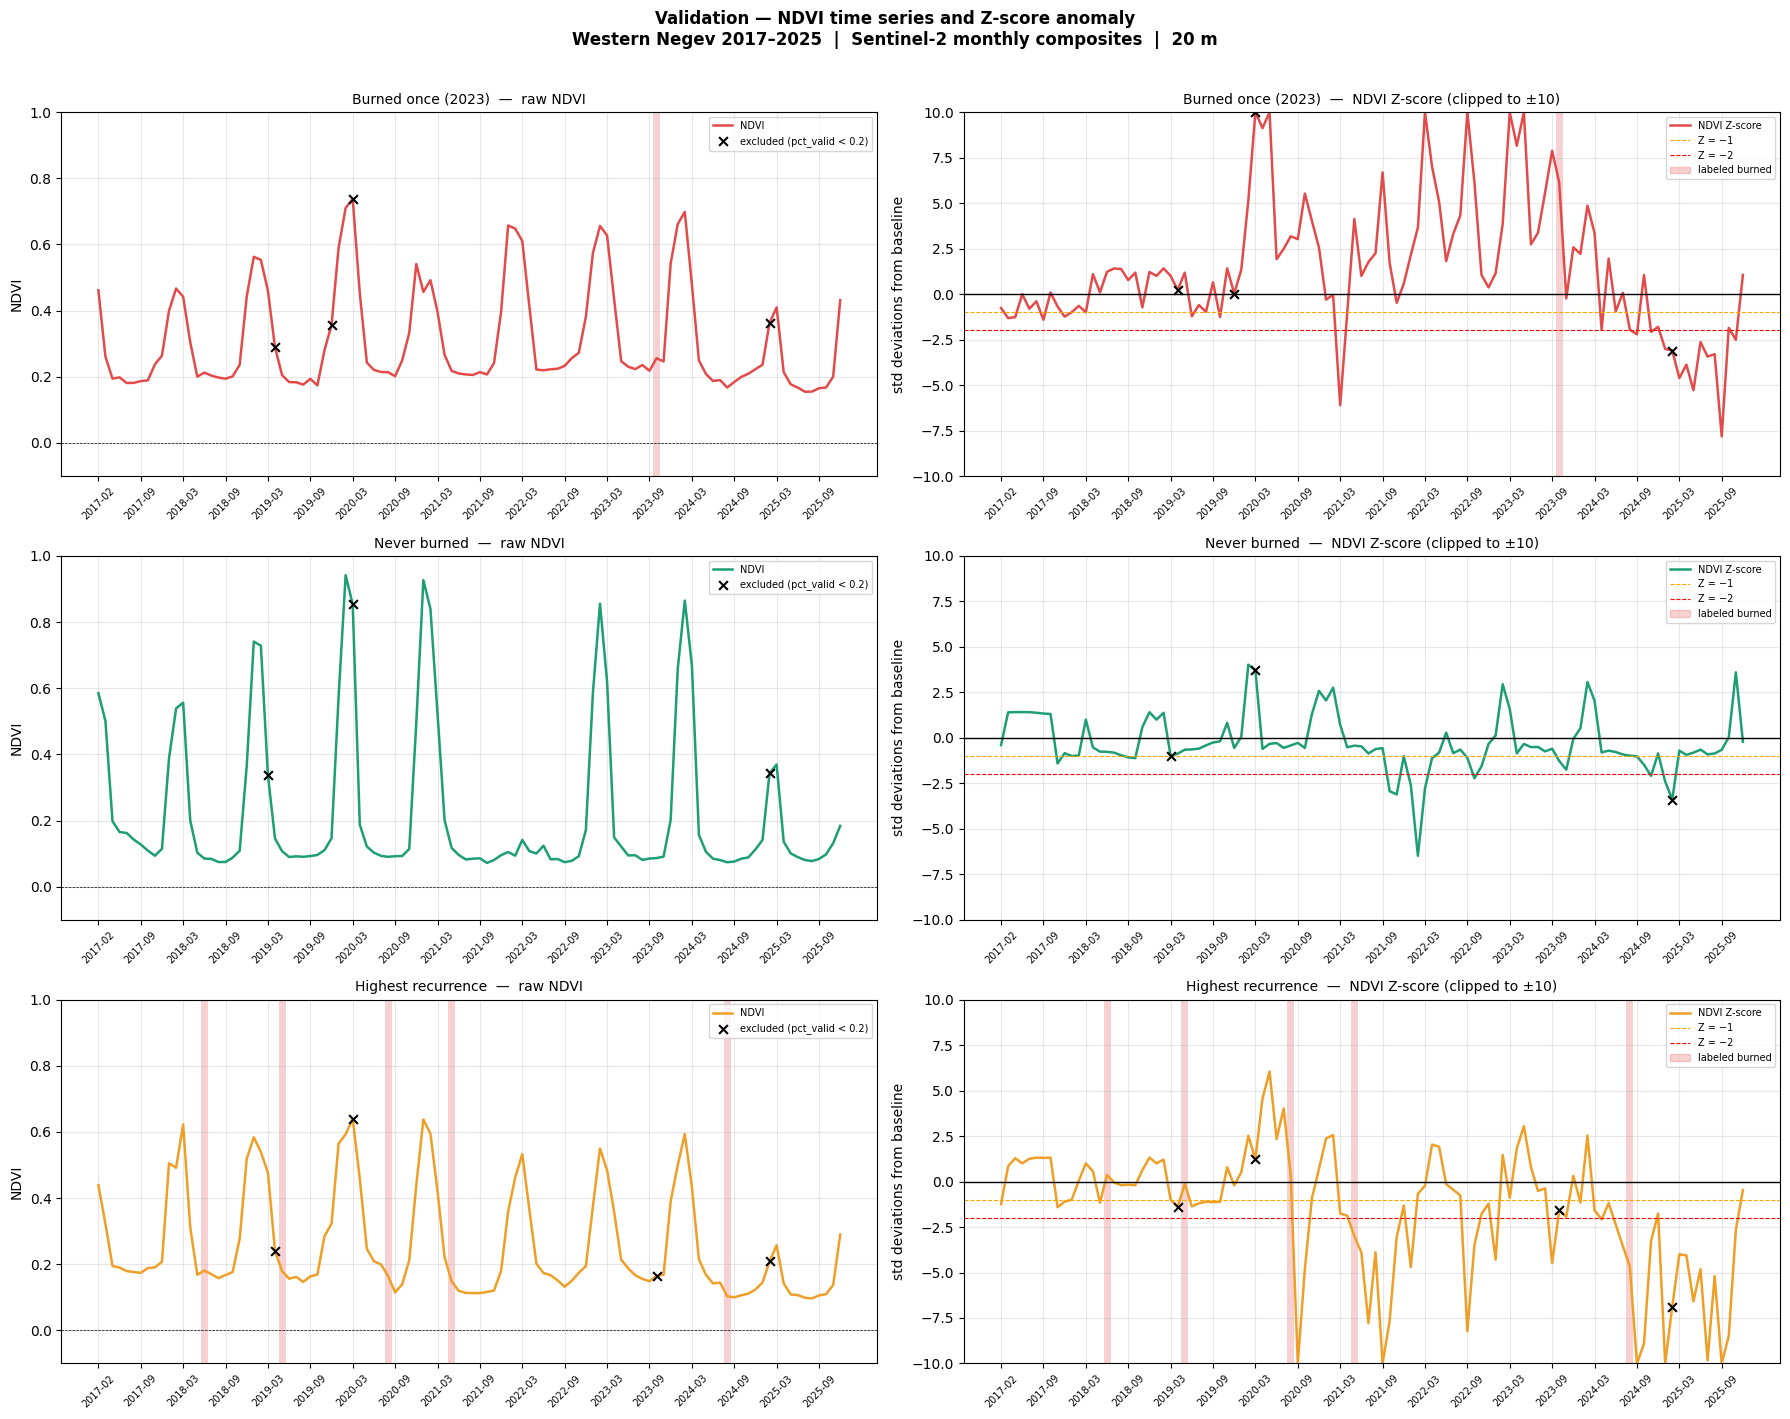

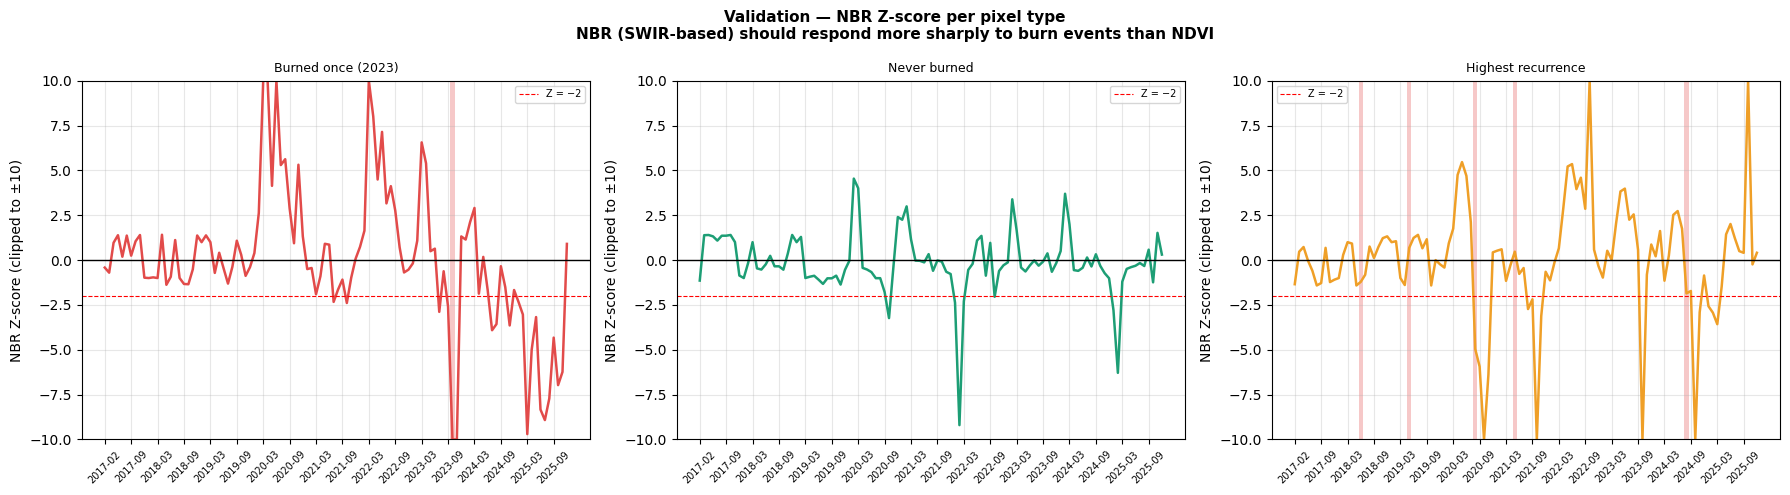

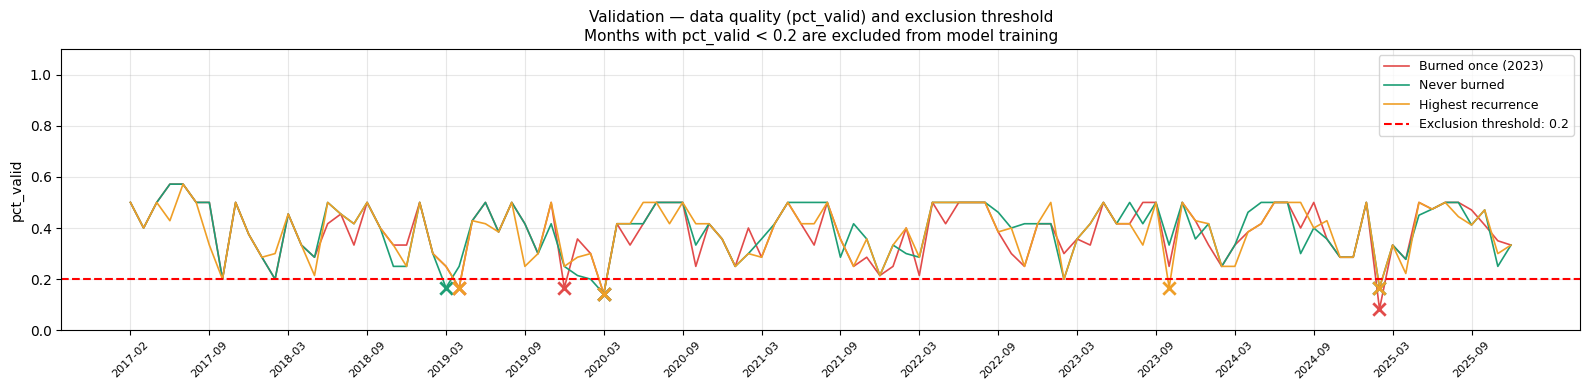

QUALITY THRESHOLD ANALYSIS
Exclusion threshold: pct_valid < 0.2

Pixel A_single_burn:
  Total months:    106
  Excluded:        4 (3.8%)
  Retained:        102 (96.2%)
    2019-04 | pct_valid=0.167 | NDVI_zscore=0.2
    2019-12 | pct_valid=0.167 | NDVI_zscore=0.0
    2020-03 | pct_valid=0.143 | NDVI_zscore=32.3
    2025-02 | pct_valid=0.083 | NDVI_zscore=-3.1

Pixel B_never_burned:
  Total months:    106
  Excluded:        3 (2.8%)
  Retained:        103 (97.2%)
    2019-03 | pct_valid=0.167 | NDVI_zscore=-1.0
    2020-03 | pct_valid=0.143 | NDVI_zscore=3.7
    2025-02 | pct_valid=0.167 | NDVI_zscore=-3.4

Pixel C_repeat_burn:
  Total months:    106
  Excluded:        4 (3.8%)
  Retained:        102 (96.2%)
    2019-04 | pct_valid=0.167 | NDVI_zscore=-1.4
    2020-03 | pct_valid=0.143 | NDVI_zscore=1.2
    2023-10 | pct_valid=0.167 | NDVI_zscore=-1.6
    2025-02 | pct_valid=0.167 | NDVI_zscore=-6.9

SUMMARY
Excluded months: ['2019-03', '2019-04', '2019-12', '2020-03', '2023-10', '2025-

In [ ]:
# ============================================================
# Validation - checking that the anomaly pipeline makes sense
# before moving to sampling and model training.
#
# Core idea: pick three representative pixels and plot their
# full time series. If the Z-score drops when the label says
# "burned", the pipeline is working. If not, something is wrong
# with the baseline or the anomaly export.
#
# Three pixel types:
#   A - burned exactly once in 2023 (clearest test case)
#   B — never burned (should show stable seasonality, Z ~ 0)
#   C — burned the most times (should show repeated drops)
#
# Pixels are selected automatically from existing assets —
# less bias and more reproducible than manual coordinate picking.
#
# Quality filtering:
#   Months with pct_valid < 0.2 are flagged and excluded.
#   Validation showed these produce |Z-score| > 10, which is
#   physically implausible and caused by cloud-contaminated
#   composites rather than real surface changes.
# ============================================================

!pip -q install geemap matplotlib
import ee, geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ee.Authenticate()
ee.Initialize(project="bar-project-457815")

# --- asset paths ---
ASSET_COLLECTION   = "projects/bar-project-457815/assets/s2_monthly_image_collection"
LABEL_COLLECTION   = "projects/bar-project-457815/assets/fire_monthly_labels"
ANOMALY_COLLECTION = "projects/bar-project-457815/assets/monthly_anomaly"
ROI_FC_ID          = "projects/bar-project-457815/assets/gaza_envelope_for_decell_Dissolve"

# quality threshold — months below this are excluded from training
# determined empirically: pct_valid < 0.2 produces |Z-score| > 10
QUALITY_THRESHOLD = 0.2

roi_fc     = ee.FeatureCollection(ROI_FC_ID)
region     = roi_fc.geometry()
ic_s2      = ee.ImageCollection(ASSET_COLLECTION)
ic_labels  = ee.ImageCollection(LABEL_COLLECTION).select("burned_this_month")
ic_anomaly = ee.ImageCollection(ANOMALY_COLLECTION)

# rebuild the spatial mask — same logic as the rest of the pipeline
landuse        = ee.FeatureCollection("projects/bar-project-457815/assets/otef_landuse")
human_infra_fc = ee.FeatureCollection(
    "projects/bar-project-457815/assets/human_infrastructure_mask_utm36n")

landuse_mask     = (landuse
                    .filter(ee.Filter.neq("FCODE", 501))
                    .reduceToImage(["FCODE"], ee.Reducer.first())
                    .gt(0))
human_infra_mask = (human_infra_fc
                    .reduceToImage(["Shape_Area"], ee.Reducer.count())
                    .gt(0))
final_mask = landuse_mask.And(human_infra_mask.Not())

# -------------------------------------------------------
# Step 1 — auto-select the three validation pixels
# -------------------------------------------------------

burn_count = (ic_labels
              .sum()
              .rename("burn_count")
              .updateMask(final_mask)
              .clip(region))

burned_2023 = (ic_labels
               .filter(ee.Filter.eq("year", 2023))
               .sum().gt(0)
               .rename("burned_2023")
               .updateMask(final_mask)
               .clip(region))

mean_ndvi = ic_s2.select("NDVI").mean().rename("mean_ndvi")

# pixel A: burned exactly once, in 2023
mask_A = burn_count.eq(1).And(burned_2023.eq(1)).selfMask()
coords_A = (ee.FeatureCollection(
                mask_A.stratifiedSample(
                    numPoints=50, classBand="burn_count",
                    region=region, scale=20, seed=42, geometries=True)
            ).first().geometry().coordinates().getInfo())
lon_A, lat_A = coords_A[0], coords_A[1]
print(f"Pixel A (single burn 2023):   {lon_A:.5f}, {lat_A:.5f}")

# pixel B: never burned, with some vegetation (NDVI > 0.15)
mask_B = (burn_count.eq(0)
          .selfMask()
          .updateMask(mean_ndvi.gt(0.15))
          .rename("burn_count"))
coords_B = (ee.FeatureCollection(
                mask_B.stratifiedSample(
                    numPoints=50, classBand="burn_count",
                    region=region, scale=20, seed=99, geometries=True)
            ).first().geometry().coordinates().getInfo())
lon_B, lat_B = coords_B[0], coords_B[1]
print(f"Pixel B (never burned):       {lon_B:.5f}, {lat_B:.5f}")

# pixel C: top 5% by burn count — highest recurrence
p95 = (burn_count.reduceRegion(
    reducer=ee.Reducer.percentile([95]),
    geometry=region, scale=20,
    maxPixels=1e13, bestEffort=True
).getInfo().get("burn_count_p95", 5))
print(f"  95th percentile burn count: {p95}")

mask_C = burn_count.gte(ee.Number(p95)).selfMask().rename("burn_count")
coords_C = (ee.FeatureCollection(
                mask_C.stratifiedSample(
                    numPoints=50, classBand="burn_count",
                    region=region, scale=20, seed=7, geometries=True)
            ).first().geometry().coordinates().getInfo())
lon_C, lat_C = coords_C[0], coords_C[1]
print(f"Pixel C (highest recurrence): {lon_C:.5f}, {lat_C:.5f}")

PIXELS = {
    "A_single_burn": {
        "lon": lon_A, "lat": lat_A,
        "description": "Burned once (2023)",
        "color": "#E24B4A"
    },
    "B_never_burned": {
        "lon": lon_B, "lat": lat_B,
        "description": "Never burned",
        "color": "#1D9E75"
    },
    "C_repeat_burn": {
        "lon": lon_C, "lat": lat_C,
        "description": "Highest recurrence",
        "color": "#EF9F27"
    },
}

# -------------------------------------------------------
# Step 2 — extract time series for each pixel
# -------------------------------------------------------

def extract_ts(lon, lat, collection, bands, scale=20):
    point = ee.Geometry.Point([lon, lat])

    def sample(img):
        vals = img.select(bands).reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=point,
            scale=scale
        )
        return ee.Feature(None,
                          vals.set("year",  img.get("year"))
                              .set("month", img.get("month")))

    df = geemap.ee_to_df(ee.FeatureCollection(collection.map(sample)))
    df = df.dropna(subset=["year", "month"])
    df["year"]  = df["year"].astype(int)
    df["month"] = df["month"].astype(int)
    df = df.sort_values(["year", "month"]).reset_index(drop=True)
    df["time_label"] = df.apply(
        lambda r: f"{int(r['year'])}-{int(r['month']):02d}", axis=1)
    return df


def extract_labels(lon, lat, scale=20):
    point = ee.Geometry.Point([lon, lat])

    def sample(img):
        vals = img.select("burned_this_month").reduceRegion(
            reducer=ee.Reducer.first(),
            geometry=point,
            scale=scale
        )
        return ee.Feature(None,
                          vals.set("year",  img.get("year"))
                              .set("month", img.get("month")))

    df = geemap.ee_to_df(ee.FeatureCollection(ic_labels.map(sample)))
    df = df.dropna(subset=["year", "month"])
    df["year"]  = df["year"].astype(int)
    df["month"] = df["month"].astype(int)
    return df.sort_values(["year", "month"]).reset_index(drop=True)


print("\nExtracting time series — ~1-2 min per pixel...")

pixel_data = {}
for name, info in PIXELS.items():
    print(f"  {name}...")

    df_s2   = extract_ts(info["lon"], info["lat"],
                         ic_s2, ["NDVI", "NBR", "pct_valid"])
    df_anom = extract_ts(info["lon"], info["lat"],
                         ic_anomaly,
                         ["NDVI_zscore", "NBR_zscore", "NDVI_anomaly"])
    df_lbl  = extract_labels(info["lon"], info["lat"])

    df = (df_s2
          .merge(df_anom[["year","month",
                           "NDVI_zscore","NBR_zscore","NDVI_anomaly"]],
                 on=["year","month"], how="left")
          .merge(df_lbl[["year","month","burned_this_month"]],
                 on=["year","month"], how="left"))

    pixel_data[name] = {"df": df, **info}
    print(f"    {len(df)} months total")

# -------------------------------------------------------
# Step 3 — validation plots
# -------------------------------------------------------

# figure 1: raw NDVI + Z-score side by side
# main check: do drops align with fire labels?

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle(
    "Validation — NDVI time series and Z-score anomaly\n"
    "Western Negev 2017–2025  |  Sentinel-2 monthly composites  |  20 m",
    fontsize=12, fontweight="bold", y=1.01
)

for row, (name, pdata) in enumerate(pixel_data.items()):
    df    = pdata["df"]
    color = pdata["color"]
    desc  = pdata["description"]

    ticks     = list(range(0, len(df), 6))
    tick_lbls = [df["time_label"].iloc[i] for i in ticks]

    # left: raw NDVI
    ax1 = axes[row, 0]
    ax1.plot(range(len(df)), df["NDVI"],
             color=color, linewidth=1.8, label="NDVI")

    for i, r in df.iterrows():
        if r.get("burned_this_month", 0) == 1:
            ax1.axvspan(i - 0.5, i + 0.5,
                        color="#E24B4A", alpha=0.25, linewidth=0)

    # mark low quality months (below exclusion threshold)
    low_q = df[df["pct_valid"] < QUALITY_THRESHOLD]
    if len(low_q):
        ax1.scatter(low_q.index, low_q["NDVI"],
                    color="black", s=40, zorder=5, marker="x",
                    linewidths=1.5,
                    label=f"excluded (pct_valid < {QUALITY_THRESHOLD})")

    ax1.set_title(f"{desc}  —  raw NDVI", fontsize=10)
    ax1.set_ylabel("NDVI")
    ax1.set_ylim(-0.1, 1.0)
    ax1.set_xticks(ticks)
    ax1.set_xticklabels(tick_lbls, rotation=45, fontsize=7)
    ax1.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax1.legend(fontsize=7)
    ax1.grid(True, alpha=0.3)

    # right: Z-score — clip display to [-10, 10] for readability
    # values outside this range are excluded months (artifacts)
    ax2 = axes[row, 1]
    zscore_clipped = df["NDVI_zscore"].clip(-10, 10)
    ax2.plot(range(len(df)), zscore_clipped,
             color=color, linewidth=1.8, label="NDVI Z-score")
    ax2.axhline(0,  color="black",  linewidth=1,   linestyle="-")
    ax2.axhline(-1, color="orange", linewidth=0.8, linestyle="--",
                label="Z = −1")
    ax2.axhline(-2, color="red",    linewidth=0.8, linestyle="--",
                label="Z = −2")

    for i, r in df.iterrows():
        if r.get("burned_this_month", 0) == 1:
            ax2.axvspan(i - 0.5, i + 0.5,
                        color="#E24B4A", alpha=0.25, linewidth=0)

    # mark excluded months on Z-score plot too
    if len(low_q):
        ax2.scatter(low_q.index,
                    zscore_clipped.iloc[low_q.index],
                    color="black", s=40, zorder=5, marker="x",
                    linewidths=1.5)

    fire_patch = mpatches.Patch(color="#E24B4A", alpha=0.25,
                                label="labeled burned")
    handles, lbls = ax2.get_legend_handles_labels()
    ax2.legend(handles=handles + [fire_patch],
               labels=lbls + ["labeled burned"], fontsize=7)

    ax2.set_title(f"{desc}  —  NDVI Z-score (clipped to ±10)", fontsize=10)
    ax2.set_ylabel("std deviations from baseline")
    ax2.set_ylim(-10, 10)
    ax2.set_xticks(ticks)
    ax2.set_xticklabels(tick_lbls, rotation=45, fontsize=7)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("validation_fig1_ndvi_zscore.png", dpi=150, bbox_inches="tight")
plt.show()

# figure 2: NBR Z-score — more burn-sensitive than NDVI

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle(
    "Validation — NBR Z-score per pixel type\n"
    "NBR (SWIR-based) should respond more sharply to burn events than NDVI",
    fontsize=11, fontweight="bold"
)

for col, (name, pdata) in enumerate(pixel_data.items()):
    df    = pdata["df"]
    color = pdata["color"]
    ax    = axes2[col]

    nbr_clipped = df["NBR_zscore"].clip(-10, 10)
    ax.plot(range(len(df)), nbr_clipped, color=color, linewidth=1.8)
    ax.axhline(0,  color="black", linewidth=1,   linestyle="-")
    ax.axhline(-2, color="red",   linewidth=0.8, linestyle="--",
               label="Z = −2")

    for i, r in df.iterrows():
        if r.get("burned_this_month", 0) == 1:
            ax.axvspan(i - 0.5, i + 0.5,
                       color="#E24B4A", alpha=0.3, linewidth=0)

    ticks     = list(range(0, len(df), 6))
    tick_lbls = [df["time_label"].iloc[i] for i in ticks]
    ax.set_xticks(ticks)
    ax.set_xticklabels(tick_lbls, rotation=45, fontsize=7)
    ax.set_title(pdata["description"], fontsize=9)
    ax.set_ylabel("NBR Z-score (clipped to ±10)")
    ax.set_ylim(-10, 10)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("validation_fig2_nbr_zscore.png", dpi=150, bbox_inches="tight")
plt.show()

# figure 3: quality threshold analysis
# documents which months are excluded and why

fig3, ax3 = plt.subplots(figsize=(16, 4))
ax3.set_title(
    f"Validation — data quality (pct_valid) and exclusion threshold\n"
    f"Months with pct_valid < {QUALITY_THRESHOLD} are excluded from model training",
    fontsize=11
)

for name, pdata in pixel_data.items():
    df = pdata["df"]
    ax3.plot(range(len(df)), df["pct_valid"],
             color=pdata["color"], linewidth=1.2,
             label=pdata["description"])

    excl = df[df["pct_valid"] < QUALITY_THRESHOLD]
    ax3.scatter(excl.index, excl["pct_valid"],
                color=pdata["color"], s=80, zorder=5,
                marker="x", linewidths=2)

ax3.axhline(QUALITY_THRESHOLD, color="red", linewidth=1.5,
            linestyle="--",
            label=f"Exclusion threshold: {QUALITY_THRESHOLD}")
ax3.set_ylabel("pct_valid")
ax3.set_ylim(0, 1.1)

ref_df    = pixel_data["A_single_burn"]["df"]
ticks     = list(range(0, len(ref_df), 6))
tick_lbls = [ref_df["time_label"].iloc[i] for i in ticks]
ax3.set_xticks(ticks)
ax3.set_xticklabels(tick_lbls, rotation=45, fontsize=8)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("validation_fig3_data_quality.png", dpi=150, bbox_inches="tight")
plt.show()

# -------------------------------------------------------
# Step 4 — quality threshold summary for thesis methods
# -------------------------------------------------------

print("=" * 60)
print("QUALITY THRESHOLD ANALYSIS")
print(f"Exclusion threshold: pct_valid < {QUALITY_THRESHOLD}")
print("=" * 60)

all_excluded = []

for name, pdata in pixel_data.items():
    df      = pdata["df"]
    excl    = df[df["pct_valid"] < QUALITY_THRESHOLD]
    kept    = df[df["pct_valid"] >= QUALITY_THRESHOLD]

    print(f"\nPixel {name}:")
    print(f"  Total months:    {len(df)}")
    print(f"  Excluded:        {len(excl)} ({100*len(excl)/len(df):.1f}%)")
    print(f"  Retained:        {len(kept)} ({100*len(kept)/len(df):.1f}%)")

    if len(excl) > 0:
        for _, r in excl.iterrows():
            z = r.get("NDVI_zscore", float("nan"))
            print(f"    {int(r['year'])}-{int(r['month']):02d} | "
                  f"pct_valid={r['pct_valid']:.3f} | "
                  f"NDVI_zscore={z:.1f}")
        all_excluded.extend(excl["time_label"].tolist())

unique_excl = sorted(set(all_excluded))
print(f"\n{'='*60}")
print("SUMMARY")
print(f"{'='*60}")
print(f"Excluded months: {unique_excl}")
print(f"Total affected:  {len(unique_excl)} out of 106 "
      f"({100*len(unique_excl)/106:.1f}% of time series)")
print("""
Rationale (for thesis methods section):
  Monthly composites with pct_valid < 0.2 are based on fewer
  than 20% cloud-free observations. Validation showed these
  months produce |Z-score| > 10, which is physically implausible
  for vegetation indices and indicates cloud contamination
  rather than real surface change. These months are flagged
  automatically via the pct_valid band and excluded from
  model training. No manual intervention is required.
""")

# -------------------------------------------------------
# Step 5 — final checklist
# -------------------------------------------------------
print("""
Expected results if pipeline is correct:

Pixel A (single burn, 2023):
  - NDVI drops in the labeled fire month
  - Z-score drops below -1 or -2 at that point
  - Z-score gradually returns toward 0 afterward (recovery)
  - NBR drop is sharper and faster than NDVI

Pixel B (never burned):
  - smooth seasonal NDVI, no sudden drops
  - Z-score stays near 0 throughout 2017-2025
  - no correlation with fire labels

Pixel C (repeat burns):
  - multiple NDVI drops across years
  - Z-score does not fully return to 0 between events
  - later fires start from a lower baseline

If any of these fail -> stop here, do not proceed to sampling.
""")

General statistics to get to know my data better (the data on gee)

ROI STATISTICS — Western Negev / Gaza Envelope

1. ROI area: 1,938.3 km²
   Total pixels at 20m: 4,845,818

2. Burn statistics (2017-2025)
   Burn count distribution:
     mean: 0.0153
     max:  5
     p50 (median): 0
     p75: 0
     p90: 0
     p95: 0
     p99: 1

3. Pixel counts by burn recurrence:
   never_burned (0 fires)        :  4,775,891 pixels
   burned 1 time                 :     56,348 pixels
   burned 2 times                :      7,227 pixels
   burned 3 times                :        755 pixels
   burned 4 times                :        126 pixels
   burned 5+ times               :         76 pixels

4. Burned pixels per year:
   2017:      3,992 pixels  (  1.60 km²)
   2018:     29,301 pixels  ( 11.72 km²)
   2019:      3,452 pixels  (  1.38 km²)
   2020:      9,291 pixels  (  3.72 km²)
   2021:     17,807 pixels  (  7.12 km²)
   2022:      1,134 pixels  (  0.45 km²)
   2023:      3,569 pixels  (  1.43 km²)
   2024:      4,913 pixels  (  1.97 km²)
   2025:        230 pi

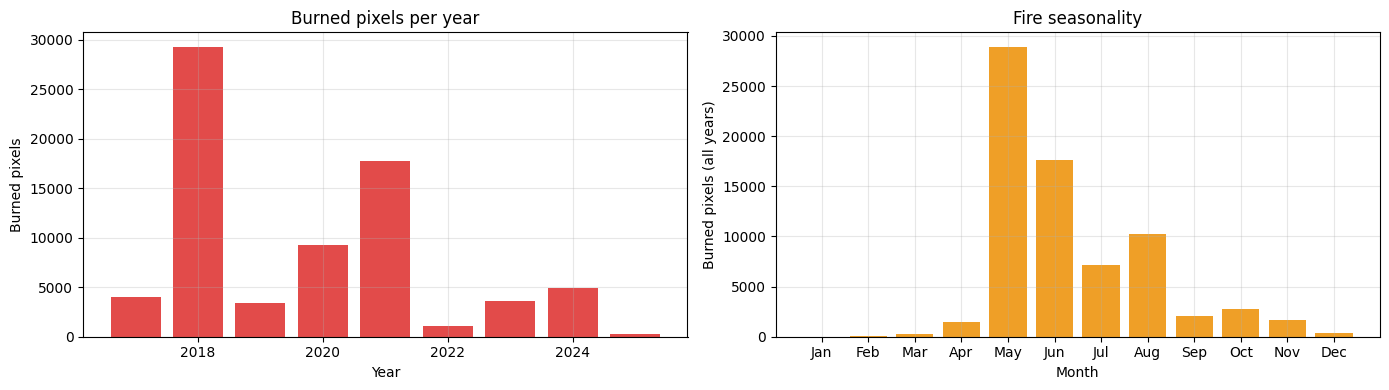


Saved: roi_statistics.png


In [14]:
# ============================================================
# ROI Statistics - understand the data before sampling
# ============================================================

import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize(project="bar-project-457815")

LABEL_COLLECTION = "projects/bar-project-457815/assets/fire_monthly_labels"
ROI_FC_ID        = "projects/bar-project-457815/assets/gaza_envelope_for_decell_Dissolve"

CRS   = "EPSG:32636"
SCALE = 20

roi_fc = ee.FeatureCollection(ROI_FC_ID)
region = roi_fc.geometry()

ic_labels = ee.ImageCollection(LABEL_COLLECTION).select("burned_this_month")

# rebuild masks
landuse = ee.FeatureCollection(
    "projects/bar-project-457815/assets/otef_landuse")
human_infra_fc = ee.FeatureCollection(
    "projects/bar-project-457815/assets/human_infrastructure_mask_utm36n")
landuse_mask = (landuse
                .filter(ee.Filter.neq("FCODE", 501))
                .reduceToImage(["FCODE"], ee.Reducer.first())
                .gt(0))
human_infra_mask = (human_infra_fc
                    .reduceToImage(["Shape_Area"], ee.Reducer.count())
                    .gt(0))
final_mask = landuse_mask.And(human_infra_mask.Not())

print("=" * 60)
print("ROI STATISTICS — Western Negev / Gaza Envelope")
print("=" * 60)

# -------------------------------------------------------
# 1. ROI area
# -------------------------------------------------------
area_m2 = region.area().getInfo()
area_km2 = area_m2 / 1e6
print(f"\n1. ROI area: {area_km2:,.1f} km²")
print(f"   Total pixels at 20m: {area_m2 / 400:,.0f}")

# -------------------------------------------------------
# 2. Burn statistics
# -------------------------------------------------------
print(f"\n2. Burn statistics (2017-2025)")

burn_count = ic_labels.sum().rename("burn_count").toInt().clip(region)

# percentiles and total
stats = burn_count.reduceRegion(
    reducer=ee.Reducer.percentile([10, 25, 50, 75, 90, 95, 99])
                      .combine(ee.Reducer.max(),  "", True)
                      .combine(ee.Reducer.mean(), "", True),
    geometry=region,
    scale=SCALE,
    crs=CRS,
    maxPixels=1e13,
    bestEffort=True
).getInfo()

print(f"   Burn count distribution:")
print(f"     mean: {stats.get('burn_count_mean'):.4f}")
print(f"     max:  {stats.get('burn_count_max')}")
print(f"     p50 (median): {stats.get('burn_count_p50')}")
print(f"     p75: {stats.get('burn_count_p75')}")
print(f"     p90: {stats.get('burn_count_p90')}")
print(f"     p95: {stats.get('burn_count_p95')}")
print(f"     p99: {stats.get('burn_count_p99')}")

# -------------------------------------------------------
# 3. Pixels per burn count category
# -------------------------------------------------------
print(f"\n3. Pixel counts by burn recurrence:")

categories = [
    ("never_burned (0 fires)",     0, 0),
    ("burned 1 time",              1, 1),
    ("burned 2 times",             2, 2),
    ("burned 3 times",             3, 3),
    ("burned 4 times",             4, 4),
    ("burned 5+ times",            5, 99),
]

for label, lo, hi in categories:
    mask = burn_count.gte(lo).And(burn_count.lte(hi))
    count = mask.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=region,
        scale=SCALE,
        crs=CRS,
        maxPixels=1e13,
        bestEffort=True
    ).getInfo().get("burn_count", 0)
    print(f"   {label:30s}: {int(count):>10,} pixels")

# -------------------------------------------------------
# 4. Burned pixels per year
# -------------------------------------------------------
print(f"\n4. Burned pixels per year:")

yearly_data = []
for year in range(2017, 2026):
    yearly = (ic_labels
              .filter(ee.Filter.eq("year", year))
              .sum()
              .gt(0)
              .clip(region))
    n = yearly.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=region,
        scale=SCALE,
        crs=CRS,
        maxPixels=1e13,
        bestEffort=True
    ).getInfo().get("burned_this_month", 0)
    n_int = int(n) if n is not None else 0
    yearly_data.append({"year": year, "burned_pixels": n_int})
    area_burned_km2 = n_int * 400 / 1e6
    print(f"   {year}: {n_int:>10,} pixels  ({area_burned_km2:6.2f} km²)")

# -------------------------------------------------------
# 5. Burned pixels per month (seasonality)
# -------------------------------------------------------
print(f"\n5. Burned pixels by month (seasonality):")

monthly_data = []
for month in range(1, 13):
    monthly = (ic_labels
               .filter(ee.Filter.eq("month", month))
               .sum()
               .gt(0)
               .clip(region))
    n = monthly.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=region,
        scale=SCALE,
        crs=CRS,
        maxPixels=1e13,
        bestEffort=True
    ).getInfo().get("burned_this_month", 0)
    n_int = int(n) if n is not None else 0
    monthly_data.append({"month": month, "burned_pixels": n_int})
    month_name = ["Jan","Feb","Mar","Apr","May","Jun",
                  "Jul","Aug","Sep","Oct","Nov","Dec"][month-1]
    print(f"   {month_name}: {n_int:>10,} pixels")

# -------------------------------------------------------
# 6. Mask impact
# -------------------------------------------------------
print(f"\n6. Spatial mask impact (landuse + infrastructure):")

# pixels in ROI
roi_pixels = ee.Image.constant(1).clip(region)
n_roi = roi_pixels.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=region,
    scale=SCALE,
    crs=CRS,
    maxPixels=1e13,
    bestEffort=True
).getInfo().get("constant", 0)

# pixels after mask
masked_pixels = roi_pixels.updateMask(final_mask)
n_masked = masked_pixels.reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=region,
    scale=SCALE,
    crs=CRS,
    maxPixels=1e13,
    bestEffort=True
).getInfo().get("constant", 0)

print(f"   Total ROI pixels:          {int(n_roi):>10,}")
print(f"   After mask (ecological):   {int(n_masked):>10,}")
print(f"   Removed (urban/agri):      {int(n_roi - n_masked):>10,}  "
      f"({100*(n_roi - n_masked)/n_roi:.1f}%)")

# -------------------------------------------------------
# 7. Visualization
# -------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# yearly
df_y = pd.DataFrame(yearly_data)
axes[0].bar(df_y["year"], df_y["burned_pixels"], color="#E24B4A")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Burned pixels")
axes[0].set_title("Burned pixels per year")
axes[0].grid(True, alpha=0.3)

# monthly
df_m = pd.DataFrame(monthly_data)
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]
axes[1].bar(month_names, df_m["burned_pixels"], color="#EF9F27")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Burned pixels (all years)")
axes[1].set_title("Fire seasonality")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("roi_statistics.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved: roi_statistics.png")
print("=" * 60)

Sample to csv for the model

extract another mask for the model

In [4]:
# ============================================================
# Step 1 — Export burn_count + mask as GeoTIFF to Drive
# Run this ONCE. Wait ~10 minutes for the export to complete.
# ============================================================

import ee
ee.Authenticate()
ee.Initialize(project="bar-project-457815")

LABEL_COLLECTION = "projects/bar-project-457815/assets/fire_monthly_labels"
ROI_FC_ID        = "projects/bar-project-457815/assets/gaza_envelope_for_decell_Dissolve"

roi_fc = ee.FeatureCollection(ROI_FC_ID)
region = roi_fc.geometry()

ic_labels = ee.ImageCollection(LABEL_COLLECTION).select("burned_this_month")

# rebuild masks (same as in your existing sampling cell)
landuse = ee.FeatureCollection(
    "projects/bar-project-457815/assets/otef_landuse")
human_infra_fc = ee.FeatureCollection(
    "projects/bar-project-457815/assets/human_infrastructure_mask_utm36n")

landuse_mask = (landuse
                .filter(ee.Filter.neq("FCODE", 501))
                .reduceToImage(["FCODE"], ee.Reducer.first())
                .gt(0))
human_infra_mask = (human_infra_fc
                    .reduceToImage(["Shape_Area"], ee.Reducer.count())
                    .gt(0))
final_mask = landuse_mask.And(human_infra_mask.Not())

# burn_count layer
burn_count = (ic_labels
              .sum()
              .rename("burn_count")
              .toInt()
              .clip(region))

# pack the mask as a second band
mask_band = (final_mask
             .rename("ecological_mask")
             .toInt()
             .unmask(0)
             .clip(region))

combined = burn_count.addBands(mask_band)

# export to Drive
task = ee.batch.Export.image.toDrive(
    image=combined,
    description="burn_count_export",
    folder="thesis_gee_exports",
    fileNamePrefix="burn_count_with_mask",
    region=region,
    scale=20,
    crs="EPSG:32636",
    maxPixels=1e13,
    fileFormat="GeoTIFF"
)
task.start()

print("Export task started.")
print("Description: burn_count_export")
print("Output file: Drive/thesis_gee_exports/burn_count_with_mask.tif")
print("\nWait ~5-10 minutes for completion.")
print("Check status here: https://code.earthengine.google.com/tasks")
print("Look for a green checkmark next to 'burn_count_export'.")

Export task started.
Description: burn_count_export
Output file: Drive/thesis_gee_exports/burn_count_with_mask.tif

Wait ~5-10 minutes for completion.
Check status here: https://code.earthengine.google.com/tasks
Look for a green checkmark next to 'burn_count_export'.


In [8]:
# ============================================================
# Step 2 — Read raster and extract pixel coordinates
# ============================================================

!pip install -q pyproj

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

import rasterio
from rasterio.transform import xy
import numpy as np
import pandas as pd
import pyproj

SEED = 42
np.random.seed(SEED)

TIF_PATH    = "/content/drive/MyDrive/thesis_gee_exports/burn_count_with_mask.tif"
COORDS_PATH = "/content/drive/MyDrive/thesis_gee_exports/pixel_coords.csv"

N_BURNED_LOW    = 4500
N_BURNED_MEDIUM = 800
N_BURNED_HIGH   = 76
N_NEVER_BURNED  = 4500

print("Reading raster...")
with rasterio.open(TIF_PATH) as src:
    burn_count = src.read(1)
    eco_mask   = src.read(2)
    transform  = src.transform
    src_crs    = src.crs
    print(f"  Shape: {burn_count.shape}")

print("\nPixel availability:")
mask_low    = (burn_count >= 1) & (burn_count <= 2)
mask_medium = (burn_count >= 3) & (burn_count <= 4)
mask_high   = (burn_count >= 5)
mask_bg     = (burn_count == 0) & (eco_mask == 1)

print(f"  burned_low    (1-2 fires):  {int(mask_low.sum()):,}")
print(f"  burned_medium (3-4 fires):  {int(mask_medium.sum()):,}")
print(f"  burned_high   (5+ fires):   {int(mask_high.sum()):,}")
print(f"  never_burned  (0 fires):    {int(mask_bg.sum()):,}")

def sample_mask(mask, n_want, label):
    rows, cols = np.where(mask)
    n_avail = len(rows)
    n_take = min(n_want, n_avail)
    print(f"  {label}: take {n_take:,} of {n_avail:,}")
    if n_avail == 0:
        return []
    idx = np.random.choice(n_avail, size=n_take, replace=False)
    return list(zip(rows[idx], cols[idx]))

print("\nSampling:")
pix_low    = sample_mask(mask_low,    N_BURNED_LOW,    "burned_low")
pix_medium = sample_mask(mask_medium, N_BURNED_MEDIUM, "burned_medium")
pix_high   = sample_mask(mask_high,   N_BURNED_HIGH,   "burned_high")
pix_bg     = sample_mask(mask_bg,     N_NEVER_BURNED,  "never_burned")

print("\nConverting to lon/lat...")
transformer = pyproj.Transformer.from_crs(
    src_crs, "EPSG:4326", always_xy=True)

def to_lonlat(pixel_list, ptype):
    out = []
    for r, c in pixel_list:
        x, y = xy(transform, r, c, offset="center")
        lon, lat = transformer.transform(x, y)
        out.append({"lon": lon, "lat": lat, "pixel_type": ptype})
    return out

records = []
records += to_lonlat(pix_low,    "burned_low")
records += to_lonlat(pix_medium, "burned_medium")
records += to_lonlat(pix_high,   "burned_high")
records += to_lonlat(pix_bg,     "never_burned")

for i, p in enumerate(records):
    p["pixel_id"] = i

df_pixels = pd.DataFrame(records)
df_pixels = df_pixels[["pixel_id", "lon", "lat", "pixel_type"]]

print(f"\nTotal pixels: {len(df_pixels)}")
print(df_pixels["pixel_type"].value_counts().to_string())

df_pixels.to_csv(COORDS_PATH, index=False)
print(f"\nSaved: {COORDS_PATH}")

Mounted at /content/drive
Reading raster...
  Shape: (3896, 2438)

Pixel availability:
  burned_low    (1-2 fires):  63,583
  burned_medium (3-4 fires):  881
  burned_high   (5+ fires):   76
  never_burned  (0 fires):    4,019,112

Sampling:
  burned_low: take 4,500 of 63,583
  burned_medium: take 800 of 881
  burned_high: take 76 of 76
  never_burned: take 4,500 of 4,019,112

Converting to lon/lat...

Total pixels: 9876
pixel_type
burned_low       4500
never_burned     4500
burned_medium     800
burned_high        76

Saved: /content/drive/MyDrive/thesis_gee_exports/pixel_coords.csv


In [9]:
# ============================================================
# Step B — Extract time series for ~9,876 pixels
# Reads coordinates from pixel_coords.csv (created by Step 2)
# ============================================================

import ee
import numpy as np
import pandas as pd
import os

# Load pre-computed coordinates from raster extraction
COORDS_PATH = "/content/drive/MyDrive/thesis_gee_exports/pixel_coords.csv"
SAVE_PATH   = "/content/drive/MyDrive/thesis_gee_exports/full_10000px.csv"

QUALITY_THRESHOLD = 0.2
SCALE             = 20
CRS               = "EPSG:32636"

# initialize GEE if not already
try:
    ee.Initialize(project="bar-project-457815")
except Exception:
    ee.Authenticate()
    ee.Initialize(project="bar-project-457815")

ic_s2      = ee.ImageCollection(
    "projects/bar-project-457815/assets/s2_monthly_image_collection")
ic_labels  = ee.ImageCollection(
    "projects/bar-project-457815/assets/fire_monthly_labels"
).select("burned_this_month")
ic_anomaly = ee.ImageCollection(
    "projects/bar-project-457815/assets/monthly_anomaly")

S2_BANDS = [
    "B2","B3","B4","B5","B6","B7","B8","B8A","B11","B12",
    "NDVI","EVI","SAVI","NDRE","NDMI","MSI",
    "NDWI","MNDWI","NBR","NBR2","MIRBI","BSI","BAIS2",
    "n_obs_valid","pct_valid"
]
ANOMALY_BANDS = [
    "NDVI_zscore","NBR_zscore","MIRBI_zscore",
    "NDMI_zscore","BSI_zscore","BAIS2_zscore","EVI_zscore",
    "NDVI_anomaly","NBR_anomaly","MIRBI_anomaly",
    "NDMI_anomaly","BSI_anomaly","BAIS2_anomaly","EVI_anomaly"
]
ALL_FEATURES = S2_BANDS + ANOMALY_BANDS

MONTHS = []
for y in range(2017, 2026):
    for m in range(1, 13):
        if y == 2017 and m == 1:
            continue
        MONTHS.append((y, m))

# -------------------------------------------------------
# Load coordinates from CSV
# -------------------------------------------------------
print("Loading pixel coordinates...")
df_coords = pd.read_csv(COORDS_PATH)
print(f"  Total: {len(df_coords)} pixels")
print(df_coords["pixel_type"].value_counts().to_string())

pixels = df_coords.to_dict("records")

# -------------------------------------------------------
# Extract time series in batches
# -------------------------------------------------------
BATCH_SIZE = 500
n_batches  = (len(pixels) + BATCH_SIZE - 1) // BATCH_SIZE

print(f"\nStep B: {len(MONTHS)} months × {len(pixels)} pixels")
print(f"  Batched into {n_batches} groups of {BATCH_SIZE}")
print(f"  Estimated time: 3-5 hours\n")

all_rows = []

for t, (year, month) in enumerate(MONTHS):

    if t % 5 == 0:
        print(f"  [{t+1}/{len(MONTHS)}] {year}-{month:02d} "
              f"— rows so far: {len(all_rows):,}")

    try:
        has_s2 = (ic_s2.filter(ee.Filter.eq("year", year))
                       .filter(ee.Filter.eq("month", month))
                       .size().gt(0))
        has_anom = (ic_anomaly.filter(ee.Filter.eq("year", year))
                              .filter(ee.Filter.eq("month", month))
                              .size().gt(0))
        has_lbl = (ic_labels.filter(ee.Filter.eq("year", year))
                            .filter(ee.Filter.eq("month", month))
                            .size().gt(0))

        s2_img = ee.Image(ee.Algorithms.If(
            has_s2,
            ic_s2.filter(ee.Filter.eq("year", year))
                 .filter(ee.Filter.eq("month", month))
                 .first().select(S2_BANDS).unmask(-9999),
            ee.Image.constant([-9999]*len(S2_BANDS))
              .rename(S2_BANDS).toFloat()
        ))
        anom_img = ee.Image(ee.Algorithms.If(
            has_anom,
            ic_anomaly.filter(ee.Filter.eq("year", year))
                      .filter(ee.Filter.eq("month", month))
                      .first().select(ANOMALY_BANDS).unmask(-9999),
            ee.Image.constant([-9999]*len(ANOMALY_BANDS))
              .rename(ANOMALY_BANDS).toFloat()
        ))
        lbl_img = ee.Image(ee.Algorithms.If(
            has_lbl,
            ic_labels.filter(ee.Filter.eq("year", year))
                     .filter(ee.Filter.eq("month", month))
                     .first().unmask(0),
            ee.Image.constant(0)
              .rename(["burned_this_month"]).toFloat()
        ))

        month_img = s2_img.addBands(anom_img).addBands(lbl_img)

        for batch_idx in range(n_batches):
            batch_start = batch_idx * BATCH_SIZE
            batch_end   = min(batch_start + BATCH_SIZE, len(pixels))
            batch_pixels = pixels[batch_start:batch_end]

            batch_fc = ee.FeatureCollection([
                ee.Feature(
                    ee.Geometry.Point([p["lon"], p["lat"]]),
                    {"pixel_id":   int(p["pixel_id"]),
                     "pixel_type": p["pixel_type"]}
                )
                for p in batch_pixels
            ])

            sampled = month_img.reduceRegions(
                collection=batch_fc,
                reducer=ee.Reducer.first(),
                scale=SCALE,
                crs=CRS
            ).getInfo()["features"]

            for feat in sampled:
                props = feat["properties"]
                row = {
                    "pixel_id":   props.get("pixel_id"),
                    "pixel_type": props.get("pixel_type"),
                    "year":       year,
                    "month":      month,
                    "burned": int(props.get("burned_this_month", 0) or 0)
                }
                for b in ALL_FEATURES:
                    row[b] = props.get(b, -9999)
                all_rows.append(row)

    except Exception as e:
        print(f"  WARNING: {year}-{month:02d}: {e}")
        continue

print(f"\nDone. Total rows: {len(all_rows):,}")

# -------------------------------------------------------
# Save
# -------------------------------------------------------
df = pd.DataFrame(all_rows)
df.replace(-9999, np.nan, inplace=True)
df_clean = df[df["pct_valid"] >= QUALITY_THRESHOLD].copy()

print(f"\nAfter quality filter: {len(df_clean):,} rows")
print(f"Burned months: {int(df_clean['burned'].sum()):,} "
      f"({100*df_clean['burned'].mean():.2f}%)")
print(f"\nPixel type distribution (final):")
print(df_clean.groupby("pixel_type")["pixel_id"].nunique().to_string())

os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
df_clean.to_csv(SAVE_PATH, index=False)
print(f"\nSaved: {SAVE_PATH}")
print(f"File size: {os.path.getsize(SAVE_PATH)/(1024*1024):.1f} MB")

Loading pixel coordinates...
  Total: 9876 pixels
pixel_type
burned_low       4500
never_burned     4500
burned_medium     800
burned_high        76

Step B: 107 months × 9876 pixels
  Batched into 20 groups of 500
  Estimated time: 3-5 hours

  [1/107] 2017-02 — rows so far: 0
  [6/107] 2017-07 — rows so far: 49,380
  [11/107] 2017-12 — rows so far: 98,760
  [16/107] 2018-05 — rows so far: 148,140
  [21/107] 2018-10 — rows so far: 197,520
  [26/107] 2019-03 — rows so far: 246,900
  [31/107] 2019-08 — rows so far: 296,280
  [36/107] 2020-01 — rows so far: 345,660
  [41/107] 2020-06 — rows so far: 395,040
  [46/107] 2020-11 — rows so far: 444,420
  [51/107] 2021-04 — rows so far: 493,800
  [56/107] 2021-09 — rows so far: 543,180


  [61/107] 2022-02 — rows so far: 592,560
  [66/107] 2022-07 — rows so far: 641,940
  [71/107] 2022-12 — rows so far: 691,320
  [76/107] 2023-05 — rows so far: 740,700
  [81/107] 2023-10 — rows so far: 790,080
  [86/107] 2024-03 — rows so far: 839,460
  [91/107] 2024-08 — rows so far: 888,840
  [96/107] 2025-01 — rows so far: 938,220
  [101/107] 2025-06 — rows so far: 987,600
  [106/107] 2025-11 — rows so far: 1,036,980

Done. Total rows: 1,056,732

After quality filter: 976,033 rows
Burned months: 7,403 (0.76%)

Pixel type distribution (final):
pixel_type
burned_high        76
burned_low       4147
burned_medium     776
never_burned     4500

Saved: /content/drive/MyDrive/thesis_gee_exports/full_10000px.csv
File size: 672.2 MB


In [3]:
# ============================================================
# Full Sampling- old version!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
#
# Strategy:
#   -  pixels stratified by burn recurrence:
#     -  burned_low    (1-2 fires)
#     -  burned_medium (3-4 fires)
#     -   burned_high   (5+ fires)
#     -  never_burned  (background)
#   - Full time series (107 months) per pixel
#   - Quality filter: pct_valid >= 0.2
#   - Output: CSV saved to Google Drive
#
# Replaces the 500-pixel pilot.
# ============================================================

import ee
import numpy as np
import pandas as pd
import os
import random
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

ee.Authenticate()
ee.Initialize(project="bar-project-457815")

LABEL_COLLECTION   = "projects/bar-project-457815/assets/fire_monthly_labels"
ASSET_COLLECTION   = "projects/bar-project-457815/assets/s2_monthly_image_collection"
ANOMALY_COLLECTION = "projects/bar-project-457815/assets/monthly_anomaly"
ROI_FC_ID          = "projects/bar-project-457815/assets/gaza_envelope_for_decell_Dissolve"

QUALITY_THRESHOLD = 0.2
SCALE             = 20
SEED              = 42
CRS               = "EPSG:32636"

# updated path - full dataset, not pilot
SAVE_PATH = "/content/drive/MyDrive/thesis_gee_exports/full_10000px.csv"

# Target counts adjusted to ROI reality
# Real availability (from ROI statistics):
#   1-2 fires: 63,575 pixels available
#   3-4 fires: 881 pixels available
#   5+ fires: 76 pixels available
#   never_burned: 4.7M pixels available
N_BURNED_LOW    = 4500   # 1-2 fires
N_BURNED_MEDIUM = 800    # 3-4 fires (almost all available)
N_BURNED_HIGH   = 76     # 5+ fires (take all)
N_NEVER_BURNED  = 4500   # background

# Total target: ~9,876 pixels

random.seed(SEED)

roi_fc = ee.FeatureCollection(ROI_FC_ID)
region = roi_fc.geometry()

ic_s2      = ee.ImageCollection(ASSET_COLLECTION)
ic_labels  = ee.ImageCollection(LABEL_COLLECTION).select("burned_this_month")
ic_anomaly = ee.ImageCollection(ANOMALY_COLLECTION)

landuse = ee.FeatureCollection(
    "projects/bar-project-457815/assets/otef_landuse")
human_infra_fc = ee.FeatureCollection(
    "projects/bar-project-457815/assets/human_infrastructure_mask_utm36n")
landuse_mask = (landuse
                .filter(ee.Filter.neq("FCODE", 501))
                .reduceToImage(["FCODE"], ee.Reducer.first())
                .gt(0))
human_infra_mask = (human_infra_fc
                    .reduceToImage(["Shape_Area"], ee.Reducer.count())
                    .gt(0))
final_mask = landuse_mask.And(human_infra_mask.Not())

S2_BANDS = [
    "B2","B3","B4","B5","B6","B7","B8","B8A","B11","B12",
    "NDVI","EVI","SAVI","NDRE","NDMI","MSI",
    "NDWI","MNDWI","NBR","NBR2","MIRBI","BSI","BAIS2",
    "n_obs_valid","pct_valid"
]
ANOMALY_BANDS = [
    "NDVI_zscore","NBR_zscore","MIRBI_zscore",
    "NDMI_zscore","BSI_zscore","BAIS2_zscore","EVI_zscore",
    "NDVI_anomaly","NBR_anomaly","MIRBI_anomaly",
    "NDMI_anomaly","BSI_anomaly","BAIS2_anomaly","EVI_anomaly"
]
ALL_FEATURES = S2_BANDS + ANOMALY_BANDS

MONTHS = []
for y in range(2017, 2026):
    for m in range(1, 13):
        if y == 2017 and m == 1:
            continue
        MONTHS.append((y, m))

# -------------------------------------------------------
# Build burn_count
# -------------------------------------------------------
print("Building burn_count layer...")

burn_count = (ic_labels
              .sum()
              .rename("burn_count")
              .toInt()
              .clip(region))

# -------------------------------------------------------
# Step A - get pixel coordinates via reduceToVectors
# -------------------------------------------------------
print("\nStep A: extracting pixel coordinates...")
def get_pixel_coords(min_val, max_val, n_want,
                     use_final_mask=False,
                     extraction_scale=20,
                     label=""):
    """
    Use sample() directly on a masked image.
    For rare pixels (high burn count), oversample heavily so
    we hit them despite the random sampling.
    """
    masked = burn_count.updateMask(
        burn_count.gte(min_val).And(burn_count.lte(max_val))
    )
    if use_final_mask:
        masked = masked.updateMask(final_mask)

    # for rare classes, request many more samples than needed
    # because most random samples will land on the masked-out pixels
    # and be dropped (dropNulls=True)
    if max_val >= 5:
        request_n = 100000   # for burned_high (rare)
    elif max_val >= 3:
        request_n = 50000    # for burned_medium
    else:
        request_n = 20000    # for burned_low and never_burned

    print(f"  {label}: requesting {request_n} samples...")

    try:
        sampled = masked.sample(
            region=region,
            scale=extraction_scale,
            projection=CRS,
            numPixels=request_n,
            seed=SEED,
            geometries=True,
            dropNulls=True,
            tileScale=16
        )

        n_total = sampled.size().getInfo()
        print(f"  {label}: {n_total} valid pixels found "
              f"(want {n_want})")

        if n_total == 0:
            return []

        feats = sampled.getInfo()["features"]
        coords = []
        for f in feats:
            geom = f["geometry"]
            if geom and geom["type"] == "Point":
                coords.append(tuple(geom["coordinates"]))

        random.shuffle(coords)
        return coords[:n_want]

    except Exception as e:
        print(f"  {label}: failed with {e}")
        return []

# burned: native scale (20m) to capture small fire footprints
coords_low    = get_pixel_coords(1, 2, N_BURNED_LOW,
                                 use_final_mask=False,
                                 extraction_scale=20,
                                 label="burned_low")
coords_medium = get_pixel_coords(3, 4, N_BURNED_MEDIUM,
                                 use_final_mask=False,
                                 extraction_scale=20,
                                 label="burned_medium")
coords_high   = get_pixel_coords(5, 99, N_BURNED_HIGH,
                                 use_final_mask=False,
                                 extraction_scale=20,
                                 label="burned_high")
# never_burned
coords_bg     = get_pixel_coords(0, 0, N_NEVER_BURNED,
                                 use_final_mask=True,
                                 extraction_scale=20,
                                 label="never_burned")

# -------------------------------------------------------
# Build pixel list
# -------------------------------------------------------
pixels = []
pid = 0
for ptype, coords in [
    ("burned_low",    coords_low),
    ("burned_medium", coords_medium),
    ("burned_high",   coords_high),
    ("never_burned",  coords_bg)
]:
    for lon, lat in coords:
        pixels.append({
            "pixel_id":   pid,
            "lon":        lon,
            "lat":        lat,
            "pixel_type": ptype
        })
        pid += 1

print(f"\nTotal pixels: {len(pixels)}")
df_pixels = pd.DataFrame(pixels)
print(df_pixels["pixel_type"].value_counts().to_string())

n_burned = sum(1 for p in pixels if "burned" in p["pixel_type"])
if n_burned == 0:
    raise ValueError("No burned pixels.")

# -------------------------------------------------------
# Step B — extract time series in batches
#
# With 5000 pixels × 107 months, we batch the reduceRegions
# calls to avoid memory limits in GEE.
# Batch size of 500 pixels per call is safe.
# -------------------------------------------------------
BATCH_SIZE = 500
n_batches  = (len(pixels) + BATCH_SIZE - 1) // BATCH_SIZE

print(f"\nStep B: {len(MONTHS)} months × {len(pixels)} pixels")
print(f"  Batched into {n_batches} groups of {BATCH_SIZE}")
print("  Estimated time: 2-4 hours total\n")

all_rows = []

for t, (year, month) in enumerate(MONTHS):

    if t % 5 == 0:
        print(f"  [{t+1}/{len(MONTHS)}] {year}-{month:02d} "
              f"— rows so far: {len(all_rows)}")

    try:
        # build month image once
        has_s2   = (ic_s2.filter(ee.Filter.eq("year", year))
                         .filter(ee.Filter.eq("month", month))
                         .size().gt(0))
        has_anom = (ic_anomaly.filter(ee.Filter.eq("year", year))
                              .filter(ee.Filter.eq("month", month))
                              .size().gt(0))
        has_lbl  = (ic_labels.filter(ee.Filter.eq("year", year))
                              .filter(ee.Filter.eq("month", month))
                              .size().gt(0))

        s2_img = ee.Image(ee.Algorithms.If(
            has_s2,
            ic_s2.filter(ee.Filter.eq("year", year))
                 .filter(ee.Filter.eq("month", month))
                 .first().select(S2_BANDS).unmask(-9999),
            ee.Image.constant([-9999]*len(S2_BANDS))
              .rename(S2_BANDS).toFloat()
        ))
        anom_img = ee.Image(ee.Algorithms.If(
            has_anom,
            ic_anomaly.filter(ee.Filter.eq("year", year))
                      .filter(ee.Filter.eq("month", month))
                      .first().select(ANOMALY_BANDS).unmask(-9999),
            ee.Image.constant([-9999]*len(ANOMALY_BANDS))
              .rename(ANOMALY_BANDS).toFloat()
        ))
        lbl_img = ee.Image(ee.Algorithms.If(
            has_lbl,
            ic_labels.filter(ee.Filter.eq("year", year))
                     .filter(ee.Filter.eq("month", month))
                     .first().unmask(0),
            ee.Image.constant(0)
              .rename(["burned_this_month"]).toFloat()
        ))

        month_img = s2_img.addBands(anom_img).addBands(lbl_img)

        # process pixels in batches to avoid memory errors
        for batch_idx in range(n_batches):
            batch_start = batch_idx * BATCH_SIZE
            batch_end   = min(batch_start + BATCH_SIZE, len(pixels))
            batch_pixels = pixels[batch_start:batch_end]

            batch_fc = ee.FeatureCollection([
                ee.Feature(
                    ee.Geometry.Point([p["lon"], p["lat"]]),
                    {"pixel_id": p["pixel_id"],
                     "pixel_type": p["pixel_type"]}
                )
                for p in batch_pixels
            ])

            sampled = month_img.reduceRegions(
                collection=batch_fc,
                reducer=ee.Reducer.first(),
                scale=SCALE,
                crs=CRS
            ).getInfo()["features"]

            for feat in sampled:
                props = feat["properties"]
                row = {
                    "pixel_id":   props.get("pixel_id"),
                    "pixel_type": props.get("pixel_type"),
                    "year":       year,
                    "month":      month,
                    "burned": int(props.get("burned_this_month", 0) or 0)
                }
                for b in ALL_FEATURES:
                    row[b] = props.get(b, -9999)
                all_rows.append(row)

    except Exception as e:
        print(f"  WARNING: {year}-{month:02d}: {e}")
        continue

print(f"\nDone. Total rows: {len(all_rows)}")

# -------------------------------------------------------
# Save
# -------------------------------------------------------
df = pd.DataFrame(all_rows)
df.replace(-9999, np.nan, inplace=True)
df_clean = df[df["pct_valid"] >= QUALITY_THRESHOLD].copy()

print(f"After quality filter: {len(df_clean)} rows")
print(f"Burned months: {int(df_clean['burned'].sum())} "
      f"({100*df_clean['burned'].mean():.2f}%)")
print(f"\nPixel type distribution:")
print(df_clean.groupby("pixel_type")["pixel_id"].nunique().to_string())

os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
df_clean.to_csv(SAVE_PATH, index=False)
print(f"\nSaved: {SAVE_PATH}")
print(f"File size: {os.path.getsize(SAVE_PATH)/1024/1024:.1f} MB")

Mounted at /content/drive
Building burn_count layer...

Step A: extracting pixel coordinates...
  burned_low: requesting 20000 samples...
  burned_low: 255 valid pixels found (want 4500)
  burned_medium: requesting 50000 samples...
  burned_medium: 13 valid pixels found (want 800)


KeyboardInterrupt: 

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/thesis_gee_exports/full_10000px.csv")

print("=== Quick sanity check ===")
print(f"Shape: {df.shape}")
print(f"\nPixel types: {df.groupby('pixel_type')['pixel_id'].nunique().to_dict()}")
print(f"\nBurned distribution:")
print(df.groupby("pixel_type")["burned"].agg(["sum","mean","count"]))
print(f"\nSample burned row:")
print(df[df["burned"]==1].head(2)[
    ["pixel_id","pixel_type","year","month","burned","NDVI","NBR","NDVI_zscore"]
])

In [2]:
# ============================================================
# Cell 1 - Data loading and preparation
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

DRIVE_PATH = "/content/drive/MyDrive/thesis_gee_exports/full_10000px.csv"

QUALITY_THRESHOLD = 0.2

S2_BANDS = [
    "B2","B3","B4","B5","B6","B7","B8","B8A","B11","B12",
    "NDVI","EVI","SAVI","NDRE","NDMI","MSI",
    "NDWI","MNDWI","NBR","NBR2","MIRBI","BSI","BAIS2",
    "n_obs_valid","pct_valid"
]
ANOMALY_BANDS = [
    "NDVI_zscore","NBR_zscore","MIRBI_zscore",
    "NDMI_zscore","BSI_zscore","BAIS2_zscore","EVI_zscore",
    "NDVI_anomaly","NBR_anomaly","MIRBI_anomaly",
    "NDMI_anomaly","BSI_anomaly","BAIS2_anomaly","EVI_anomaly"
]
ALL_FEATURES = S2_BANDS + ANOMALY_BANDS  # 39 features

# -------------------------------------------------------
# Load
# -------------------------------------------------------
print("Loading data...")
df = pd.read_csv(DRIVE_PATH)
df = df[df["pct_valid"] >= QUALITY_THRESHOLD].copy()
df = df.sort_values(["pixel_id","year","month"]).reset_index(drop=True)

pixel_ids   = df["pixel_id"].unique()
pixel_types = df.groupby("pixel_id")["pixel_type"].first()
T           = int(df.groupby("pixel_id").size().median())

print(f"  Pixels: {len(pixel_ids)}, T={T}, Features={len(ALL_FEATURES)}")
print(f"  Types: {pixel_types.value_counts().to_dict()}")

# -------------------------------------------------------
# Reshape to [N, T, C]
# -------------------------------------------------------
X_list, y_list, meta_list = [], [], []

for pid in pixel_ids:
    group  = df[df["pixel_id"]==pid].sort_values(["year","month"])
    feats  = group[ALL_FEATURES].values.astype(np.float32)
    labels = group["burned"].values.astype(np.float32)

    if len(feats) < T:
        pad    = T - len(feats)
        feats  = np.pad(feats,  ((0,pad),(0,0)), mode="constant")
        labels = np.pad(labels, (0,pad),          mode="constant")
    else:
        feats  = feats[:T]
        labels = labels[:T]

    X_list.append(feats)
    y_list.append(labels)
    meta_list.append({
        "pixel_id":   pid,
        "pixel_type": pixel_types[pid]
    })

X = np.stack(X_list)
y = np.stack(y_list)
print(f"  X={X.shape}, y={y.shape}")

# -------------------------------------------------------
# NaN imputation
# -------------------------------------------------------
if np.isnan(X).sum() > 0:
    col_means = np.nanmean(X.reshape(-1, X.shape[-1]), axis=0)
    for c in range(X.shape[-1]):
        mask = np.isnan(X[:,:,c])
        X[:,:,c][mask] = col_means[c]

# -------------------------------------------------------
# Normalize
# -------------------------------------------------------
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(
    X.reshape(-1, X.shape[-1])
).reshape(X.shape).astype(np.float32)

# -------------------------------------------------------
# Train/Val/Test split — binary stratification
# burned_high has only 2 pixels so we stratify by
# burned (any) vs never_burned only
# -------------------------------------------------------
meta_df = pd.DataFrame(meta_list)
meta_df["stratum"] = meta_df["pixel_type"].apply(
    lambda t: "burned" if "burned" in t else "never_burned"
)

print(f"  Strata: {meta_df['stratum'].value_counts().to_dict()}")

idx = list(range(len(pixel_ids)))

train_idx, temp_idx = train_test_split(
    idx, test_size=0.30, random_state=42,
    stratify=meta_df["stratum"]
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=42,
    stratify=meta_df.iloc[temp_idx]["stratum"].values
)

X_train = X_scaled[train_idx]
X_val   = X_scaled[val_idx]
X_test  = X_scaled[test_idx]
y_train = y[train_idx]
y_val   = y[val_idx]
y_test  = y[test_idx]

print(f"\nSplit: Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

burned_frac = y_train.mean()
pos_weight  = (1 - burned_frac) / (burned_frac + 1e-6)
print(f"Burned months (train): {100*burned_frac:.2f}%")
print(f"pos_weight: {pos_weight:.1f}")

for name, sidx in [("train",train_idx),("val",val_idx),("test",test_idx)]:
    types = meta_df.iloc[sidx]["pixel_type"].value_counts().to_dict()
    print(f"  {name}: {types}")

print("\nCell 1 complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading data...
  Pixels: 9499, T=103, Features=39
  Types: {'never_burned': 4500, 'burned_low': 4147, 'burned_medium': 776, 'burned_high': 76}
  X=(9499, 103, 39), y=(9499, 103)
  Strata: {'burned': 9499}

Split: Train=6649, Val=1425, Test=1425
Burned months (train): 0.76%
pos_weight: 130.0
  train: {'never_burned': 3130, 'burned_low': 2913, 'burned_medium': 550, 'burned_high': 56}
  val: {'never_burned': 673, 'burned_low': 628, 'burned_medium': 110, 'burned_high': 14}
  test: {'never_burned': 697, 'burned_low': 606, 'burned_medium': 116, 'burned_high': 6}

Cell 1 complete.


Cell 2 — הגדרת המודל


In [3]:
# ============================================================
# Cell 2 — Model definition
#
# L-TAE (Lightweight Temporal Attention Encoder)
# based on Garnot & Landrieu (2020), adapted for:
#   - tabular pixel time series (not image patches)
#   - multi-task output (burned detection + RPS components)
#
# Architecture:
#   Input projection → L-TAE encoder → multi-task heads
#
# References:
#   Garnot & Landrieu (2020) — L-TAE
#   Garnot & Landrieu (2020) — PSE+TAE (CVPR)
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# -------------------------------------------------------
# L-TAE: Lightweight Temporal Attention Encoder
# -------------------------------------------------------

class LTAE(nn.Module):
    """
    Lightweight Temporal Attention Encoder.

    For each pixel, encodes a time series of shape [T, d_model]
    into a single context vector of shape [d_model] using
    multi-head self-attention with a learned master query per head.

    Each head specializes in a different part of the time series —
    this gives interpretable attention masks showing which months
    the model focuses on for each pixel.
    """

    def __init__(self, d_model=128, n_head=4, d_k=32, dropout=0.1):
        super().__init__()
        self.n_head  = n_head
        self.d_model = d_model
        self.d_k     = d_k

        # one master query per head — learned parameter
        # (this is what makes L-TAE "lightweight" vs full TAE)
        self.master_query = nn.Parameter(
            torch.randn(n_head, d_k) * 0.1
        )

        # key projection: maps each time step to keys
        self.key_proj = nn.Linear(d_model // n_head, d_k, bias=False)

        self.dropout  = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        """
        x:    [B, T, d_model]
        mask: [B, T] — True for valid months, False for padded
        returns: [B, d_model]
        """
        B, T, D = x.shape
        H = self.n_head
        d_head = D // H

        # split channels across heads: [B, T, H, d_head]
        x_heads = x.view(B, T, H, d_head)

        # compute keys for each head: [B, T, H, d_k]
        keys = self.key_proj(x_heads)

        # master query: [H, d_k] → [1, 1, H, d_k] → [B, 1, H, d_k]
        q = self.master_query.unsqueeze(0).unsqueeze(0).expand(B, 1, H, self.d_k)

        # attention scores: [B, T, H]
        scores = (keys * q).sum(dim=-1) / math.sqrt(self.d_k)

        # apply mask — set padding positions to -inf
        if mask is not None:
            # mask: [B, T] → [B, T, 1]
            scores = scores.masked_fill(
                (~mask).unsqueeze(-1).expand_as(scores),
                float("-inf")
            )

        # softmax over time axis
        attn = F.softmax(scores, dim=1)  # [B, T, H]
        attn = self.dropout(attn)

        # save for interpretability
        self.attention_weights = attn.detach()

        # weighted sum of values (values = input embeddings)
        # [B, T, H, 1] * [B, T, H, d_head] → [B, H, d_head]
        context = (attn.unsqueeze(-1) * x_heads).sum(dim=1)

        # flatten heads: [B, H*d_head] = [B, d_model]
        context = context.view(B, D)
        context = self.layer_norm(context)

        return context


# -------------------------------------------------------
# Full model: input projection + L-TAE + multi-task heads
# -------------------------------------------------------

class FireRecoveryModel(nn.Module):
    """
    Full model for fire dynamics + RPS prediction.

    Outputs:
      1. burned_logits — per-month fire detection [B, T] (binary)
      2. severity      — auxiliary RPS component [B] (regression)
      3. persistence   — auxiliary RPS component [B] (regression)
      4. recovery      — auxiliary RPS component [B] (regression)
      5. rps           — direct RPS prediction [B] (regression)

    The direct RPS head learns end-to-end against analytically-derived
    targets, making the model's main output the RPS itself rather than
    a post-hoc computation.
    """

    def __init__(self, n_features=39, d_model=128,
                 n_head=4, d_k=32, dropout=0.1):
        super().__init__()
        self.d_model = d_model

        self.input_proj = nn.Sequential(
            nn.Linear(n_features, d_model),
            nn.LayerNorm(d_model),
            nn.GELU(),
            nn.Dropout(dropout)
        )

        self.ltae = LTAE(
            d_model=d_model, n_head=n_head,
            d_k=d_k, dropout=dropout
        )

        # burned detection — per time step
        self.head_burned = nn.Sequential(
            nn.Linear(d_model * 2, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

        # RPS component heads — auxiliary tasks for representation learning
        self.head_severity = nn.Sequential(
            nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(64, 1), nn.Sigmoid()
        )
        self.head_persistence = nn.Sequential(
            nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(64, 1), nn.Sigmoid()
        )
        self.head_recovery = nn.Sequential(
            nn.Linear(d_model, 64), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(64, 1), nn.Sigmoid()
        )

        # NEW: direct RPS head — primary output for the thesis
        # learns end-to-end to predict the analytically-derived RPS
        self.head_rps = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x, mask=None):
        B, T, C = x.shape
        h       = self.input_proj(x)
        context = self.ltae(h, mask)

        # burned detection (per time step)
        context_exp  = context.unsqueeze(1).expand(B, T, -1)
        burned_input = torch.cat([h, context_exp], dim=-1)
        burned_logits = self.head_burned(burned_input).squeeze(-1)

        # auxiliary RPS components
        severity    = self.head_severity(context).squeeze(-1)
        persistence = self.head_persistence(context).squeeze(-1)
        recovery    = self.head_recovery(context).squeeze(-1)

        # NEW: direct RPS prediction
        rps = self.head_rps(context).squeeze(-1)

        return {
            "burned_logits": burned_logits,
            "severity":      severity,
            "persistence":   persistence,
            "recovery":      recovery,
            "rps":           rps,
        }

    def compute_rps_analytic(self, outputs,
                             weights=(0.3, 0.3, 0.2, 0.2)):
        """
        Analytical RPS — used to generate training targets.
        After training, prefer outputs['rps'] (the learned head).
        """
        w1, w2, w3, w4 = weights
        recurrence = torch.sigmoid(
            outputs["burned_logits"]).mean(dim=1)
        rps = (w1 * recurrence +
               w2 * outputs["severity"] +
               w3 * outputs["persistence"] +
               w4 * (1 - outputs["recovery"]))
        return rps.clamp(0, 1)

    def get_attention_weights(self):
        return self.ltae.attention_weights


# -------------------------------------------------------
# Loss function — multi-task
# -------------------------------------------------------

class MultiTaskLoss(nn.Module):
    """
    Combined loss for fire detection + RPS components.

    Primary task (burned detection):
      Binary cross-entropy with pos_weight to handle
      class imbalance (most months are not burned).

    Auxiliary tasks (severity, persistence, recovery):
      Derived analytically from the data — see compute_targets().
      MSE loss against these derived targets.

    The auxiliary tasks help the model learn meaningful
    representations of fire dynamics, not just binary detection.
    """

    def __init__(self, pos_weight=10.0, lambda_aux=0.3):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor(pos_weight)
        )
        self.mse = nn.MSELoss()
        self.lambda_aux = lambda_aux  # weight of auxiliary losses

    def forward(self, outputs, targets):
        """
        outputs: dict from FireRecoveryModel.forward()
        targets: dict with keys:
            burned        [B, T]
            severity      [B]
            persistence   [B]
            recovery      [B]
        """
        # primary: burned detection
        loss_burned = self.bce(
            outputs["burned_logits"],
            targets["burned"]
        )

        # auxiliary: RPS components
        loss_severity    = self.mse(outputs["severity"],
                                    targets["severity"])
        loss_persistence = self.mse(outputs["persistence"],
                                    targets["persistence"])
        loss_recovery    = self.mse(outputs["recovery"],
                                    targets["recovery"])

        loss_aux = (loss_severity + loss_persistence + loss_recovery) / 3

        total = loss_burned + self.lambda_aux * loss_aux

        return {
            "total":       total,
            "burned":      loss_burned,
            "auxiliary":   loss_aux,
            "severity":    loss_severity,
            "persistence": loss_persistence,
            "recovery":    loss_recovery
        }

def compute_targets(X, y, feature_names,
                    rps_weights=(0.25, 0.25, 0.25, 0.25)):
    """
    Compute auxiliary targets including RPS.

    RPS = w1·recurrence + w2·severity + w3·persistence + w4·(1-recovery)

    Equal weights (0.25 each) used as a neutral baseline.
    Final weights to be determined via AHP or sensitivity analysis
    in a later iteration.
    """

    N, T, C = X.shape

    try:
        nbr_z_idx = feature_names.index("NBR_zscore")
    except ValueError:
        nbr_z_idx = feature_names.index("NBR")

    severity    = np.zeros(N, dtype=np.float32)
    persistence = np.zeros(N, dtype=np.float32)
    recovery    = np.zeros(N, dtype=np.float32)
    recurrence  = np.zeros(N, dtype=np.float32)
    has_burned  = np.zeros(N, dtype=np.float32)

    for i in range(N):
        nbr_z        = X[i, :, nbr_z_idx]
        burned        = y[i]
        burned_months = np.where(burned == 1)[0]

        if len(burned_months) == 0:
            # never burned — all components stay 0
            continue

        has_burned[i] = 1.0

        # recurrence - normalize so 5+ fires gives 1.0
        recurrence[i] = float(np.clip(burned.sum() / 5.0, 0, 1))

        # severity: mean negative anomaly during fire months
        drops = -nbr_z[burned_months]
        severity[i] = float(np.clip(drops.mean() / 5.0, 0, 1))

        # persistence: fraction of post-fire months with depressed NBR
        last_fire = burned_months[-1]
        post_fire = nbr_z[last_fire:]
        if len(post_fire) > 1:
            persistence[i] = float((post_fire < -0.5).mean())

        # recovery: slope of NBR z-score after last fire
        # higher slope = better recovery = LOWER priority
        if len(post_fire) > 3:
            t     = np.arange(len(post_fire), dtype=np.float32)
            slope = np.polyfit(t, post_fire, 1)[0]
            recovery[i] = float(np.clip((slope + 0.1) / 0.2, 0, 1))

    # RPS - gated by has_burned so never_burned pixels get 0
    w1, w2, w3, w4 = rps_weights
    rps_target = has_burned * (
        w1 * recurrence +
        w2 * severity +
        w3 * persistence +
        w4 * (1 - recovery)
    )
    rps_target = np.clip(rps_target, 0, 1).astype(np.float32)

    return {
        "severity":    torch.tensor(severity),
        "persistence": torch.tensor(persistence),
        "recovery":    torch.tensor(recovery),
        "rps":         torch.tensor(rps_target),
    }


print("Model definition complete.")
print(f"\nModel summary:")
model = FireRecoveryModel(n_features=len(ALL_FEATURES))
total_params = sum(p.numel() for p in model.parameters())
print(f"  Total parameters: {total_params:,}")
print(f"  Architecture: Input({len(ALL_FEATURES)}) → "
      f"L-TAE(d={128}, H=4) → MultiTask(4 heads)")

Model definition complete.

Model summary:
  Total parameters: 58,629
  Architecture: Input(39) → L-TAE(d=128, H=4) → MultiTask(4 heads)


# Cell 3 — Training loop and evaluation


Device: cpu
Computing auxiliary targets...

Training for 50 epochs (Focal Loss)...
 Epoch | Train Loss |  Val Loss |  Val AUC
------------------------------------------
     1 |     0.0240 |    0.0127 |   0.8420
     5 |     0.0107 |    0.0102 |   0.9182
    10 |     0.0095 |    0.0090 |   0.9377
    15 |     0.0088 |    0.0088 |   0.9518
    20 |     0.0081 |    0.0083 |   0.9575
    25 |     0.0076 |    0.0080 |   0.9612
    30 |     0.0070 |    0.0078 |   0.9651
    35 |     0.0067 |    0.0077 |   0.9657
    40 |     0.0065 |    0.0076 |   0.9668
    45 |     0.0064 |    0.0075 |   0.9670
    50 |     0.0063 |    0.0075 |   0.9673

Best val AUC: 0.9673

Tuning decision threshold on validation set...
  Best threshold: 0.286
  Best val F1 at this threshold: 0.5851


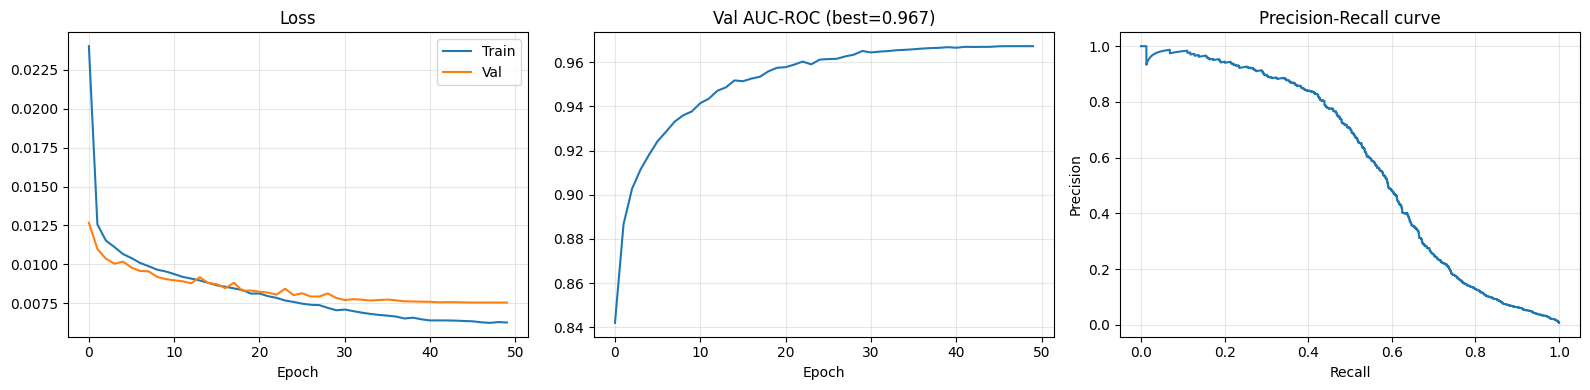


Test set evaluation with tuned threshold...
Correlation learned vs analytic RPS: -0.939

Threshold: 0.286
              precision    recall  f1-score   support

  not burned       1.00      1.00      1.00    145702
      burned       0.68      0.47      0.56      1073

    accuracy                           0.99    146775
   macro avg       0.84      0.74      0.78    146775
weighted avg       0.99      0.99      0.99    146775

AUC-ROC: 0.9638


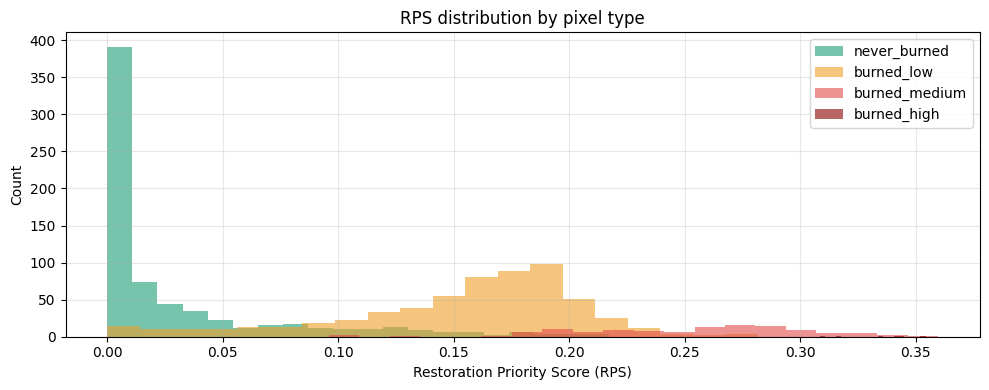


 Complete.
  AUC: 0.967 - primary metric for imbalanced data
  Best threshold: 0.286


In [4]:
# ============================================================
# Cell 3 — Updated Training
# Two fixes:
# 1. threshold tuning — find optimal decision boundary
# 2. focal loss instead of BCE — better for imbalanced data
# ============================================================

import torch
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (f1_score, roc_auc_score,
                             classification_report,
                             precision_recall_curve)

DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
N_EPOCHS   = 50
BATCH_SIZE = 32
LR         = 1e-3
print(f"Device: {DEVICE}")

# -------------------------------------------------------
# Focal Loss — better than BCE for extreme imbalance
#
# Focal loss down-weights easy negatives (not-burned months
# that the model already classifies correctly) and focuses
# training on the hard positives (burned months).
# gamma=2 is standard; alpha balances pos/neg weight.
# -------------------------------------------------------

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce  = F.binary_cross_entropy_with_logits(
            logits, targets, reduction="none")
        prob = torch.sigmoid(logits)
        p_t  = prob * targets + (1 - prob) * (1 - targets)
        loss = bce * ((1 - p_t) ** self.gamma)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_t * loss
        return loss.mean()


class MultiTaskLossFocal(nn.Module):
    """
    Multi-task loss combining:
      - Focal loss on burned detection (per month)
      - MSE on RPS components (severity, persistence, recovery)
      - MSE on the direct RPS prediction (PRIMARY task for thesis)

    The RPS loss has the highest weight because it is the main
    output of interest for the Restoration Priority Score heatmap.
    """

    def __init__(self, alpha=0.25, gamma=2.0,
                 lambda_aux=0.3, lambda_rps=1.0):
        super().__init__()
        self.focal      = FocalLoss(alpha=alpha, gamma=gamma)
        self.mse        = nn.MSELoss()
        self.lambda_aux = lambda_aux
        self.lambda_rps = lambda_rps

    def forward(self, outputs, targets):
        # primary auxiliary task — burned detection
        loss_burned = self.focal(
            outputs["burned_logits"], targets["burned"])

        # auxiliary RPS components
        loss_sev = self.mse(outputs["severity"],
                            targets["severity"])
        loss_per = self.mse(outputs["persistence"],
                            targets["persistence"])
        loss_rec = self.mse(outputs["recovery"],
                            targets["recovery"])
        loss_aux = (loss_sev + loss_per + loss_rec) / 3

        # NEW: direct RPS regression — the main task
        loss_rps = self.mse(outputs["rps"], targets["rps"])

        total = (loss_burned +
                 self.lambda_aux * loss_aux +
                 self.lambda_rps * loss_rps)

        return {
            "total":       total,
            "burned":      loss_burned,
            "auxiliary":   loss_aux,
            "rps":         loss_rps,
        }


# -------------------------------------------------------
# Compute auxiliary targets
# -------------------------------------------------------
print("Computing auxiliary targets...")
train_targets_aux = compute_targets(X_train, y_train, ALL_FEATURES)
val_targets_aux   = compute_targets(X_val,   y_val,   ALL_FEATURES)

# -------------------------------------------------------
# Data Loaders
# -------------------------------------------------------
def make_loader(X, y, targets_aux, batch_size, shuffle):
    dataset = TensorDataset(
        torch.tensor(X), torch.tensor(y),
        targets_aux["severity"],
        targets_aux["persistence"],
        targets_aux["recovery"],
        targets_aux["rps"],            # NEW
    )
    return DataLoader(dataset, batch_size=batch_size,
                      shuffle=shuffle, drop_last=False)

train_loader = make_loader(X_train, y_train,
                           train_targets_aux, BATCH_SIZE, True)
val_loader   = make_loader(X_val, y_val,
                           val_targets_aux, BATCH_SIZE, False)

# -------------------------------------------------------
# Model + optimizer
# -------------------------------------------------------
model     = FireRecoveryModel(n_features=len(ALL_FEATURES)).to(DEVICE)
criterion = MultiTaskLossFocal(alpha=0.25, gamma=2.0, lambda_aux=0.3)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=N_EPOCHS)

# -------------------------------------------------------
# Training loop
# -------------------------------------------------------
history = {"train_loss": [], "val_loss": [],
           "val_f1": [], "val_auc": []}

best_val_auc = 0.0
best_weights = None

print(f"\nTraining for {N_EPOCHS} epochs (Focal Loss)...")
print(f"{'Epoch':>6} | {'Train Loss':>10} | "
      f"{'Val Loss':>9} | {'Val AUC':>8}")
print("-" * 42)

for epoch in range(1, N_EPOCHS + 1):

    # train
    model.train()
    train_losses = []
    for batch in train_loader:
        X_b, y_b, sev_b, per_b, rec_b, rps_b = [b.to(DEVICE) for b in batch]
        optimizer.zero_grad()
        outputs = model(X_b)
        targets = {
            "burned":      y_b,
            "severity":    sev_b,
            "persistence": per_b,
            "recovery":    rec_b,
            "rps":         rps_b,
        }
        losses  = criterion(outputs, targets)
        losses["total"].backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_losses.append(losses["total"].item())
    scheduler.step()

    # validate
    model.eval()
    val_losses, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            X_b, y_b, sev_b, per_b, rec_b, rps_b = [b.to(DEVICE) for b in batch]

            outputs = model(X_b)
            targets = {"burned": y_b, "severity": sev_b,
                                  "persistence": per_b, "recovery": rec_b,
                                  "rps": rps_b}
            losses  = criterion(outputs, targets)
            val_losses.append(losses["total"].item())
            probs = torch.sigmoid(outputs["burned_logits"])
            all_probs.extend(probs.cpu().flatten().numpy())
            all_labels.extend(y_b.cpu().flatten().numpy())

    train_loss = np.mean(train_losses)
    val_loss   = np.mean(val_losses)
    try:
        val_auc = roc_auc_score(all_labels, all_probs)
    except Exception:
        val_auc = 0.0

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_auc"].append(val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_weights = {k: v.cpu().clone()
                        for k, v in model.state_dict().items()}

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6} | {train_loss:>10.4f} | "
              f"{val_loss:>9.4f} | {val_auc:>8.4f}")

print(f"\nBest val AUC: {best_val_auc:.4f}")

# -------------------------------------------------------
# Threshold tuning on validation set
#
# Instead of always using 0.5, find the threshold that
# maximizes F1 on the validation set.
# This is critical for imbalanced problems.
# -------------------------------------------------------
print("\nTuning decision threshold on validation set...")
model.load_state_dict(best_weights)
model.eval()

val_probs_all, val_labels_all = [], []
with torch.no_grad():
    for batch in val_loader:
        X_b, y_b = batch[0].to(DEVICE), batch[1].to(DEVICE)
        outputs  = model(X_b)
        probs    = torch.sigmoid(outputs["burned_logits"])
        val_probs_all.extend(probs.cpu().flatten().numpy())
        val_labels_all.extend(y_b.cpu().flatten().numpy())

val_probs_arr  = np.array(val_probs_all)
val_labels_arr = np.array(val_labels_all)

# sweep thresholds and find best F1
thresholds = np.linspace(0.01, 0.99, 200)
f1_scores  = []
for thr in thresholds:
    preds = (val_probs_arr >= thr).astype(float)
    f1    = f1_score(val_labels_arr, preds,
                     zero_division=0, pos_label=1)
    f1_scores.append(f1)

best_thr = thresholds[np.argmax(f1_scores)]
best_f1  = max(f1_scores)
print(f"  Best threshold: {best_thr:.3f}")
print(f"  Best val F1 at this threshold: {best_f1:.4f}")

# plot precision-recall curve
precision, recall, pr_thresholds = precision_recall_curve(
    val_labels_arr, val_probs_arr)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["val_auc"])
axes[1].set_title(f"Val AUC-ROC (best={best_val_auc:.3f})")
axes[1].set_xlabel("Epoch")
axes[1].grid(True, alpha=0.3)

axes[2].plot(recall, precision)
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Precision-Recall curve")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves_v2.png", dpi=150, bbox_inches="tight")
plt.show()

# -------------------------------------------------------
# Test set evaluation with tuned threshold
# -------------------------------------------------------
print("\nTest set evaluation with tuned threshold...")
X_test_t = torch.tensor(X_test).to(DEVICE)
y_test_t = torch.tensor(y_test)

with torch.no_grad():
    outputs = model(X_test_t)
    test_probs = torch.sigmoid(
        outputs["burned_logits"]).cpu().flatten().numpy()
    # use the learned RPS head (primary thesis output)
    rps_learned = outputs["rps"]
    # also keep analytical RPS for comparison
    rps_analytic = model.compute_rps_analytic(outputs)

    # correlation between learned and analytical
    from scipy.stats import pearsonr
    corr, _ = pearsonr(rps_learned.cpu().numpy(), rps_analytic.cpu().numpy())
    print(f"Correlation learned vs analytic RPS: {corr:.3f}")

    rps = rps_learned   # use learned RPS for the heatmap
test_labels = y_test_t.flatten().numpy()
test_preds  = (test_probs >= best_thr).astype(float)

print(f"\nThreshold: {best_thr:.3f}")
print(classification_report(
    test_labels, test_preds,
    target_names=["not burned", "burned"],
    zero_division=0))

try:
    print(f"AUC-ROC: {roc_auc_score(test_labels, test_probs):.4f}")
except Exception:
    print("AUC-ROC: could not compute")

# -------------------------------------------------------
# RPS distribution
# -------------------------------------------------------
rps_np           = rps.cpu().numpy()
pixel_type_test  = [meta_list[i]["pixel_type"]
                    for i in list(test_idx)]

fig2, ax = plt.subplots(figsize=(10, 4))
colors   = {"never_burned":  "#1D9E75",
            "burned_low":    "#EF9F27",
            "burned_medium": "#E24B4A",
            "burned_high":   "#8B0000"}

for ptype in ["never_burned", "burned_low",
              "burned_medium", "burned_high"]:
    mask = [t == ptype for t in pixel_type_test]
    if any(mask):
        ax.hist(rps_np[mask], bins=20, alpha=0.6,
                label=ptype, color=colors[ptype])

ax.set_xlabel("Restoration Priority Score (RPS)")
ax.set_ylabel("Count")
ax.set_title("RPS distribution by pixel type")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("rps_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n Complete.")
print(f"  AUC: {best_val_auc:.3f} - primary metric for imbalanced data")
print(f"  Best threshold: {best_thr:.3f}")

for the report

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.1 MB/s eta 0:00:00


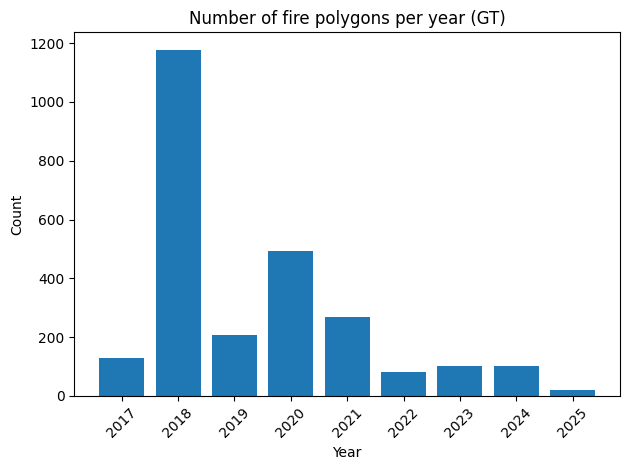

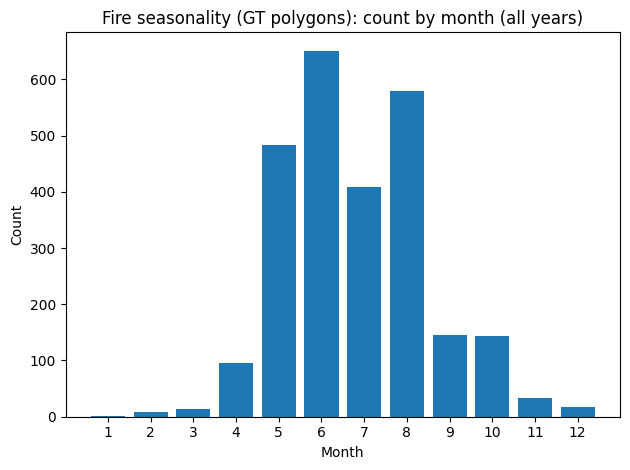

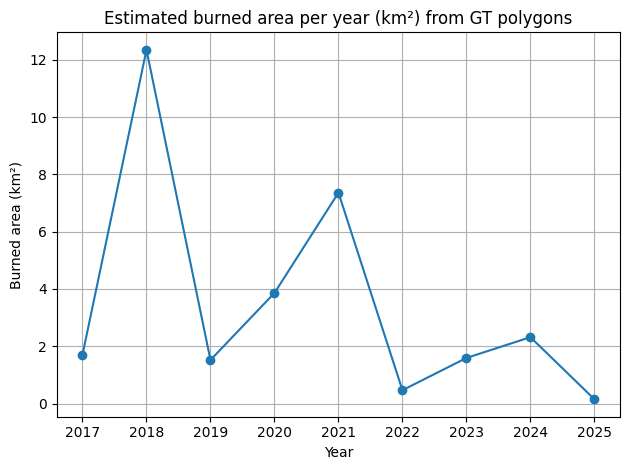

In [ ]:
# ============================
# COLAB: Thesis-ready outputs
# ============================
!pip -q install geemap

import ee, geemap
import pandas as pd
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize(project="bar-project-457815")

# ---- Assets ----
ASSET_COLLECTION = "projects/bar-project-457815/assets/s2_monthly_image_collection"
LABEL_COLLECTION = "projects/bar-project-457815/assets/fire_monthly_labels"

# ---- Load ROI + masks + GT (use your existing assets) ----
working_area = ee.FeatureCollection("projects/bar-project-457815/assets/gaza_envelope_for_decell_Dissolve")
region = working_area.geometry()

landuse = ee.FeatureCollection("projects/bar-project-457815/assets/otef_landuse")
human_infra_fc = ee.FeatureCollection("projects/bar-project-457815/assets/human_infrastructure_mask_utm36n")

landuse_mask = (landuse
                .filter(ee.Filter.neq("FCODE", 501))
                .reduceToImage(["FCODE"], ee.Reducer.first())
                .gt(0))

human_infra_mask = (human_infra_fc
                    .reduceToImage(["Shape_Area"], ee.Reducer.count())
                    .gt(0))

final_mask = landuse_mask.And(human_infra_mask.Not())

fires_truth = (ee.FeatureCollection("projects/bar-project-457815/assets/fires_scars_otef_6991")
               .filterBounds(region)
               .map(lambda f: f.set({
                    "fire_date": ee.Date(ee.Number(f.get("FireDate"))),
                    "fire_year": ee.Date(ee.Number(f.get("FireDate"))).get("year"),
                    "system:time_start": ee.Number(f.get("FireDate"))
                })))

START = ee.Date("2017-01-01").millis()
END   = ee.Date("2025-12-31").millis()
fires_clean = fires_truth.filter(ee.Filter.rangeContains("FireDate", START, END))

# A raster: burned anywhere (all years)
burned_any = ee.Image(0).toByte().paint(fires_clean, 1).rename("burned_any")

# ---- Load monthly assets ----
ic_monthly = ee.ImageCollection(ASSET_COLLECTION)
ic_labels  = ee.ImageCollection(LABEL_COLLECTION)  # if you exported labels

# Helper: get monthly image by year/month (works even if filterDate is unreliable)
def get_monthly_img(ic, year, month):
    return (ee.Image(
        ic.filter(ee.Filter.eq("year", year))
          .filter(ee.Filter.eq("month", month))
          .first()
    ))

# -----------------------------
# 1) Maps to screenshot for report
# -----------------------------
m = geemap.Map(center=[31.35, 34.55], zoom=10)

m.addLayer(working_area.style(**{"color":"yellow","fillColor":"00000000","width":2}), {}, "ROI boundary")
m.addLayer(landuse_mask.selfMask(), {"min":0,"max":1}, "landuse_mask (kept)")
m.addLayer(human_infra_mask.selfMask(), {"min":0,"max":1}, "human_infra_mask (excluded)")
m.addLayer(final_mask.selfMask(), {"min":0,"max":1}, "final_mask (ROI usable)")
m.addLayer(burned_any.selfMask(), {"min":0,"max":1}, "burned_any (GT, all years)")

# Example month visualization
YEAR, MONTH = 2017, 10
img = get_monthly_img(ic_monthly, YEAR, MONTH)

rgbVis = {"bands":["B4","B3","B2"], "min":0.03, "max":0.35, "gamma":1.2}
ndviVis = {"min":0.0, "max":0.9}
nbrVis  = {"min":-0.5, "max":0.8}

m.addLayer(img.clip(region), rgbVis, f"RGB {YEAR}-{MONTH:02d}")
m.addLayer(img.select("NDVI").clip(region), ndviVis, f"NDVI {YEAR}-{MONTH:02d}")
m.addLayer(img.select("NBR").clip(region),  nbrVis,  f"NBR {YEAR}-{MONTH:02d}")

# Show where data exists (mask)
m.addLayer(img.select("B4").mask().clip(region), {}, f"Mask (data exists) {YEAR}-{MONTH:02d}")

m

# -----------------------------
# 2) Fire counts per year (polygons)
# -----------------------------
hist_year = fires_clean.aggregate_histogram("fire_year")
hist_year = ee.Dictionary(hist_year).getInfo()

df_year = (pd.DataFrame({"year": list(hist_year.keys()), "n_fires": list(hist_year.values())})
             .assign(year=lambda d: d["year"].astype(int))
             .sort_values("year"))

plt.figure()
plt.bar(df_year["year"], df_year["n_fires"])
plt.title("Number of fire polygons per year (GT)")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(df_year["year"], rotation=45)
plt.tight_layout()
plt.show()

# -----------------------------
# 3) Seasonality: fires per month aggregated over all years
# -----------------------------
# Build month column from FireDate millis
def add_month(f):
    d = ee.Date(ee.Number(f.get("FireDate")))
    return f.set("fire_month", d.get("month"))  # 1..12

fires_with_month = fires_clean.map(add_month)
hist_month = fires_with_month.aggregate_histogram("fire_month")
hist_month = ee.Dictionary(hist_month).getInfo()

df_month = (pd.DataFrame({"month": list(hist_month.keys()), "n_fires": list(hist_month.values())})
             .assign(month=lambda d: d["month"].astype(int))
             .sort_values("month"))

plt.figure()
plt.bar(df_month["month"], df_month["n_fires"])
plt.title("Fire seasonality (GT polygons): count by month (all years)")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(range(1,13))
plt.tight_layout()
plt.show()

# -----------------------------
# 4) Burned area per year (km^2) from polygons (rasterize per year)
# -----------------------------
SCALE = 20
MAX_PIXELS = 1e10

def burned_area_km2_for_year(y):
    y = ee.Number(y)
    fires_y = fires_clean.filter(ee.Filter.eq("fire_year", y))
    burned_y = ee.Image(0).toByte().paint(fires_y, 1).rename("burned_y").clip(region)
    # area = sum( burned_y * pixelArea )
    area_m2 = (burned_y
               .multiply(ee.Image.pixelArea())
               .reduceRegion(
                    reducer=ee.Reducer.sum(),
                    geometry=region,
                    scale=SCALE,
                    maxPixels=MAX_PIXELS
                ).get("burned_y"))
    return ee.Feature(None, {"year": y, "burned_km2": ee.Number(area_m2).divide(1e6)})

years = ee.List.sequence(2017, 2025)
fc_area = ee.FeatureCollection(years.map(burned_area_km2_for_year))
df_area = geemap.ee_to_df(fc_area).sort_values("year")

plt.figure()
plt.plot(df_area["year"], df_area["burned_km2"], marker="o")
plt.title("Estimated burned area per year (km²) from GT polygons")
plt.xlabel("Year")
plt.ylabel("Burned area (km²)")
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 5) Fire recurrence / frequency map (if you exported monthly labels)
# -----------------------------
# fire_freq = sum of burned_this_month across all months
# (If LABEL_COLLECTION is empty/not exported yet, this will fail.)
try:
    fire_freq = ic_labels.select("burned_this_month").sum().rename("fire_frequency").clip(region)
    m2 = geemap.Map(center=[31.35, 34.55], zoom=10)
    m2.addLayer(fire_freq.selfMask(), {"min":1, "max":10}, "Fire frequency (2017-2025)")
    m2.addLayer(working_area.style(**{"color":"yellow","fillColor":"00000000","width":2}), {}, "ROI boundary")
    m2
except Exception as e:
    print("Labels collection not ready or missing:", e)

In [ ]:
!pip -q install -U geemap
import ee, geemap

ee.Authenticate()
ee.Initialize(project="bar-project-457815")

ROI_FC_ID    = "projects/bar-project-457815/assets/gaza_envelope_for_decell_Dissolve"
LABELS_IC_ID = "projects/bar-project-457815/assets/fire_monthly_labels"

roi_fc = ee.FeatureCollection(ROI_FC_ID)
region = roi_fc.geometry()

labels_ic = ee.ImageCollection(LABELS_IC_ID).select("burned_this_month")

# Sum over all months: per pixel = number of months burned
burn_count = labels_ic.sum().rename("burn_count").clip(region)

# Make zeros transparent (only show pixels that burned >= 1)
burn_count_nonzero = burn_count.updateMask(burn_count.gt(0))

# Use percentiles for a nicer color stretch
stats = burn_count.reduceRegion(
    reducer=ee.Reducer.percentile([50, 90, 95, 99]).combine(ee.Reducer.max(), "", True),
    geometry=region,
    scale=20,
    maxPixels=1e13,
    bestEffort=True,
    tileScale=4
).getInfo()

p50 = stats.get("burn_count_p50", 1)
p90 = stats.get("burn_count_p90", 1)
p95 = stats.get("burn_count_p95", 1)
p99 = stats.get("burn_count_p99", 1)
mx  = stats.get("burn_count_max", 1)

print("Burn count stats:", {"p50": p50, "p90": p90, "p95": p95, "p99": p99, "max": mx})

# Choose display max as p99 (usually best for visualization)
disp_max = max(1, int(p99))

# Bright, intuitive heat palette (yellow -> orange -> red -> dark red)
vis = {
    "min": 1,
    "max": disp_max,
    "palette": ["ffffb2","fed976","feb24c","fd8d3c","f03b20","bd0026","800026"]
}

m = geemap.Map()
m.centerObject(roi_fc, 10)

# ROI outline for context
m.addLayer(roi_fc.style(color="white", fillColor="00000000", width=2), {}, "ROI outline")

# Main heatmap (zeros are transparent now)
m.addLayer(burn_count_nonzero, vis, f"Times burned (min=1, max=p99={disp_max})")

# Optional: add a semi-transparent mask of ROI (helps screenshots)
# m.addLayer(ee.Image().paint(region, 1), {"palette": ["000000"], "opacity": 0.05}, "ROI shade")

m

Burn count stats: {'p50': 0, 'p90': 0, 'p95': 0, 'p99': 1, 'max': 5}


Map(center=[31.36506302258509, 34.54933616729509], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
labels_ic = ee.ImageCollection("projects/bar-project-457815/assets/fire_monthly_labels")
roi_fc    = ee.FeatureCollection("projects/bar-project-457815/assets/gaza_envelope_for_decell_Dissolve")
region    = roi_fc.geometry()

recurrence = (labels_ic.select("burned_this_month")
              .sum()
              .rename("burn_count")
              .clip(region))